In [1]:
# To be able to make edits to repo without having to restart notebook
%load_ext autoreload
%autoreload 2

In [2]:
import sys, os
sys.path.append(os.path.dirname(os.getcwd()))

import json
import pathlib
import pandas as pd
import mongomock
import xarray as xr
import cv2
from scipy import signal
import numpy as np
from fsspec.implementations.local import LocalFileSystem
from pathlib import Path
import matplotlib.pyplot as plt
from signalstore import UnitOfWorkProvider
from pymongo import MongoClient
import shutil


In [3]:
# Functions

def deserialize_dataarray(data_object):
        """Deserializes a data object.
        Arguments:
            data_object {dict} -- The data object to deserialize.
        Returns:
            dict -- The deserialized data object.
        """
        attrs = data_object.attrs.copy()
        for key, value in attrs.items():
            if isinstance(value, str):
                value = value.replace("'", '"')
                if value.lower() == 'true':
                    attrs[key] = True
                elif value.lower() == 'false':
                    attrs[key] = False
                elif value.lower() == 'none':
                    attrs[key] = None
                elif value.startswith('{'):
                    attrs[key] = json.loads(value)
            if isinstance(value, np.ndarray):
                attrs[key] = value.tolist()
        data_object.attrs = attrs
        return data_object


In [4]:
print('Ran inside Vscode') 

Ran inside Vscode


In [9]:
# Mock DB client
mongo_uri = os.environ.get("MONGO_URI", "mongodb://localhost:27017")
mongo_client = MongoClient(mongo_uri)
# -------------------------------------------------------------------

# 1) Define your container‐side data root (where "input" and "internal" are siblings)
# DATA_ROOT     = Path.cwd().parent / "data"
# INPUT_DIR     = DATA_ROOT / "input"
# INTERNAL_DIR  = DATA_ROOT / "internal"
# INTERNAL_DIR.mkdir(parents=True, exist_ok=True)


#filesystem: clear the internal data directory
tmpdir = Path.cwd().parent / "data" / "internal"
if not tmpdir.exists():
    tmpdir.mkdir(parents=True, exist_ok=True)
# for file_path in tmpdir.glob("*"):
#     if file_path.is_file():
#         file_path.unlink()
#         print(f"Deleted: {file_path}")


tmpdir = pathlib.Path(tmpdir)
filesystem = LocalFileSystem(root=str(tmpdir))
# filesystem = LocalFileSystem(root=str(DATA_ROOT))

# clear tmpdir
# for file in filesystem.ls(tmpdir):
#     print(file)
    # filesystem.rm(file)

# Empty memory store for demo
memory_store = dict()

# Get uow to act on database
uow_provider = UnitOfWorkProvider(mongo_client, filesystem, memory_store)
unit_of_work = uow_provider(str(tmpdir.name))
shutil.rmtree("./internal", ignore_errors=True)
with unit_of_work as uow:
    uow.data._data._directory = str(tmpdir)


# Get raw_property_models
property_models_path = Path.cwd().parent / r"tests" / r"data" / r"valid_data" / r"models" / r"property_models.json"
with open(property_models_path, 'r') as file:
    raw_property_models = json.load(file)

# Get raw_metamodels
metamodels_dir = Path.cwd().parent / r"tests" / r"data" / r"valid_data" / r"models" / r"metamodels"
metamodel_filepaths = list(metamodels_dir.glob("*.json"))
raw_metamodels = []
for filepath in metamodel_filepaths:
    with open(filepath, 'r') as file:
        raw_metamodels.append(json.load(file))

# Get raw_data_models
data_models_dir = Path.cwd().parent / r"tests" / r"data" / r"valid_data" / r"models" / r"data_models"
data_model_filepaths = list(data_models_dir.glob("*.json"))
raw_data_models = []
for filepath in data_model_filepaths:
    with open(filepath, 'r') as file:
        raw_data_models.append(json.load(file))

# Get raw_records
netcdf_dir = Path.cwd().parent / r"data" / r"input"
records_files = list(netcdf_dir.glob("*.xlsx"))
raw_records = []
for filepath in records_files:
        file = pd.read_excel(filepath, engine='openpyxl', dtype=str)
        file_json = file.to_json(orient="records")
        records = json.loads(file_json)
        raw_records.extend(records)

# Get dataarrays

netcdf_files = list(netcdf_dir.glob("*.nc"))
dataarrays = []
for filepath in netcdf_files:
    # print(filepath)
    dataarray = xr.open_dataarray(filepath)
    dataarray = deserialize_dataarray(dataarray)
    dataarrays.append(dataarray)

# Add property models, metamodels, data models, and records
with unit_of_work as uow:
    for property_model in raw_property_models:
        if not uow.domain_models.exists(property_model['schema_name']):
            print(f"Adding {property_model['schema_name']} to Mongo.")
            uow.domain_models.add(property_model)
        else:
            print(f"Model {property_model['schema_name']} already exists; skipping.")
    for metamodel in raw_metamodels:
        if not uow.domain_models.exists(metamodel['schema_name']):
            print(f"Adding {metamodel['schema_name']} to Mongo.")
            uow.domain_models.add(metamodel)
        else:
            print(f"Model {metamodel['schema_name']} already exists; skipping.")
    for data_model in raw_data_models:
        if not uow.domain_models.exists(data_model['schema_name']):
            print(f"Adding {data_model['schema_name']} to Mongo.")
            uow.domain_models.add(data_model)
        else:
            print(f"Model {data_model['schema_name']} already exists; skipping.")
    for record in raw_records:
        if not record.get("has_file"):
            schema_ref = record.get("schema_ref")
            data_name = record.get("data_name")
            version_timestamp = record.get("version_timestamp")  # Could be None if not defined
    
            if not uow.data.exists(schema_ref, data_name, version_timestamp):
                uow.data.add(record)
                print(f"Adding {schema_ref}/{data_name} to Mongo.")
            else:
                # You might update or log that the record already exists
                print(f"Record with schema_ref {schema_ref} and data_name {data_name} already exists.")
    for dataarray in dataarrays:
        # Skip dataarrays with schema_ref of "test"
        if dataarray.attrs.get("schema_ref") == "test":
            continue    
        # Extract the required identifying attributes from the dataarray's attrs
        schema_ref = dataarray.attrs.get("schema_ref")
        data_name = dataarray.attrs.get("data_name")
    
        # Check whether the data array already exists in the repository.
        # Note: if you're using a specific data adapter, pass it in; otherwise, it will use the default.
        if not uow.data.has_file(schema_ref, data_name):
            print(f"Adding {schema_ref}/{data_name} to Mongo.")
            uow.data.add(dataarray)
        # if not uow.data.exists(schema_ref, data_name, version_timestamp) \
        # or not uow.data.has_file(schema_ref, data_name, version_timestamp):
        #     print(f"Adding {schema_ref}/{data_name} to Mongo and file system.")
        #     uow.data._data.add(dataarray)
        else:
            print(f"{schema_ref}/{data_name} already in Mongo _and_ file exists; skipping.")

    uow.commit()

Model version_timestamp already exists; skipping.
Model schema_ref already exists; skipping.
Model schema_type already exists; skipping.
Model schema_name already exists; skipping.
Model schema_title already exists; skipping.
Model schema_description already exists; skipping.
Model data_name already exists; skipping.
Model time_of_save already exists; skipping.
Model time_of_removal already exists; skipping.
Model record_type already exists; skipping.
Model json_schema already exists; skipping.
Model has_file already exists; skipping.
Model unit_of_measure already exists; skipping.
Model dimension_of_measure already exists; skipping.
Model acquisition already exists; skipping.
Model acquisition_date already exists; skipping.
Model import_date already exists; skipping.
Model acquisition_notes already exists; skipping.
Model data_dimensions already exists; skipping.
Model shape already exists; skipping.
Model dtype already exists; skipping.
Model session_description already exists; skipp

In [8]:
# Example query for all session records
with unit_of_work as uow:
    query = {
        "schema_ref": 'tet_waveforms'
    }
    # sorted_by = [("session_start", -1)]
    sessions = uow.data.find(query)

    for i in range(len(sessions)):
        print(sessions[i])


{'session_data_ref': {'schema_ref': 'session', 'data_name': '1-13_20210510_110723'}, 'animal_data_ref': {'schema_ref': 'animal', 'data_name': '1-13'}, 'probe_data_ref': {'schema_ref': 'probe', 'data_name': '1'}, 'has_file': True, 'schema_ref': 'tet_waveforms', 'data_name': '1-13_1_20210510_110723', 'data_dimensions': ['spike_idx', 'channel', 'sample'], 'dimension_of_measure': '[charge]', 'time_of_save': datetime.datetime(2025, 6, 3, 0, 47, 35, 744288), 'time_of_removal': None}
{'session_data_ref': {'schema_ref': 'session', 'data_name': '1-13_20210510_163938'}, 'animal_data_ref': {'schema_ref': 'animal', 'data_name': '1-13'}, 'probe_data_ref': {'schema_ref': 'probe', 'data_name': '1'}, 'has_file': True, 'schema_ref': 'tet_waveforms', 'data_name': '1-13_1_20210510_163938', 'data_dimensions': ['spike_idx', 'channel', 'sample'], 'dimension_of_measure': '[charge]', 'time_of_save': datetime.datetime(2025, 6, 3, 0, 47, 33, 107204), 'time_of_removal': None}
{'session_data_ref': {'schema_ref': 

In [7]:
# Example query for all session records
with unit_of_work as uow:
    query = {
        "schema_ref": "session"
    }
    sorted_by = [("session_start", -1)]
    sessions = uow.data.find(query)

    for i in range(len(sessions)):
        print(sessions[i])


{'schema_ref': 'session', 'data_name': '1-13_20210510_110723', 'animal_id': '1-13', 'session_date': '2021-05-10', 'session_time': '11:07:23', 'tetrode_depth': '1200', 'stimulus_id': 'NO', 'duration': '1200.0', 'duration_unit': 'second', 'stimulus_type': 'NO', 'time_of_save': datetime.datetime(2025, 4, 30, 15, 51, 9, 812188), 'time_of_removal': None}
{'schema_ref': 'session', 'data_name': '1-13_20210510_163938', 'animal_id': '1-13', 'session_date': '2021-05-10', 'session_time': '16:39:38', 'tetrode_depth': '1200', 'stimulus_id': 'NO', 'duration': '1201.0', 'duration_unit': 'second', 'stimulus_type': 'NO', 'time_of_save': datetime.datetime(2025, 4, 30, 15, 51, 9, 823182), 'time_of_removal': None}
{'schema_ref': 'session', 'data_name': '1-13_20210511_104628', 'animal_id': '1-13', 'session_date': '2021-05-11', 'session_time': '10:46:28', 'tetrode_depth': '1200', 'stimulus_id': 'NO', 'duration': '1201.0', 'duration_unit': 'second', 'stimulus_type': 'NO', 'time_of_save': datetime.datetime(20

In [8]:
def view_query_factory(uow, query, cell_id=None, exclude=None):
    """ 
    Example custom use case by user to get a dictionary of xarray datasets 

    Arguments:

    uow {UnitOfWork} -- Unit of work instance
    query {dict} -- Query to filter data with schema_ref and data_name as keys
    cell_id {numeric} -- Optional cell id to filter data for a single cell
    exclude {list} -- Optional list of schema_refs to exclude from query

    Outputs:

    query_dataset {dict} -- Dictionary of xarray datasets

    Example use case:

    To query across multiple sets of data and organize neural data while excluding behavioral data

    E.g. can get dictionary of multiple session with spike times/labels/waveforms organized. Can filter by session, tetrode, animal and other relevant schema. 
    Can also restrict to one cell over time and exclude schema like position which are behavioral recordings.

    """
    # first get query data
    query_data = uow.data.find(query)

    # empty output dict
    session_data = {}

    # go through each schema obtained by the query
    for _, d in enumerate(query_data):

        schema_ref = d['schema_ref'] # e.g. session, animal_position, spike_times, spike_labels
        data_name = d['data_name'] # data_name is id that references schema, e.g. 'ANT-133a-4_20180517_133858' for session or '3' for probe id
        # data_names are custom ids with components determined by user to ensure unique data_names 

        # custom addition to exclude schema_ref = animak_position
        # animal_position is consistent across tetrodes in a recording session and should be excluded
        # when querying neural data 
        if exclude is not None and schema_ref in exclude:
                continue

        # retrieve data and add to dictionary ensuring no duplicates 
        # also organizes different schema_ref with same data_name (e.g. spike times and labels for same session)
        if data_name not in session_data:
            session_data[data_name] = {}
        retrieved_data = uow.data.get(schema_ref, data_name)
        assert schema_ref not in session_data[data_name], f"Data already exists for {schema_ref} in {data_name}"
        session_data[data_name][schema_ref] = retrieved_data

    # organize sets of schema_refs into datasets for hte unique sessions collected
    # index is data_name of session
    query_dataset = {name: xr.Dataset(data) for name, data in session_data.items()}
    # query_dataset = [xr.Dataset(data) for name, data in session_data.items()]
    
    # optionally filter each dataset by a cell_id 
    # only valid if cell_ids are matched across sessions (true in our data)
    if cell_id is not None:
        query_dataset = {name: _filter_cell_data(data, cell_id) for name, data in query_dataset.items()}
        
    return query_dataset

# helper fxn to only select single cell label
def _filter_cell_data(data, cell_id):
    """Get data for a single cell"""
    filtered_data = data.where(data.spike_labels == int(cell_id), drop=True)
    return filtered_data



In [9]:
""" EXAMPLE QUERIES """

# simple (single session) and complex (multi-session) queries are shown

with unit_of_work as uow:

    sample = '1-13_20210510_110723'

    # Single session and tetrode
    query = {
        "session_data_ref": {'schema_ref': 'session', 'data_name': sample},
        "probe_data_ref": {'schema_ref': 'probe', 'data_name': '1'}
    }
    data = view_query_factory(uow, query)
    print('data:', data)
    print("single session and tetrode")
    print("Collected " + str(len(data)) + " session with " + str(len(data[next(iter(data))])) + " data variables")
    print(data[next(iter(data))].data_vars)
    ncount = len(set(list(data[next(iter(data))].spike_labels[:,0].values)))
    print("Dataset has {} cell appearances".format(ncount))
    
    # All sessions and single tetrode
    query = {
        "probe_data_ref": {'schema_ref': 'probe', 'data_name': '1'}
    }
    session_datasets = view_query_factory(uow, query)
    print("\nall sessions and single tetrode")
    print("Collected " + str(len(session_datasets.keys())) + " sessions with 3 data variables")
    print(session_datasets[next(iter(data))].data_vars)
    ncount = sum([len(set(list(session_datasets[session].spike_labels[:,0].values))) for session in session_datasets])
    print("Dataset has {} cell appearances".format(ncount))

    # All sessions, single tetrode and single cell
    query = {
        "probe_data_ref": {'schema_ref': 'probe', 'data_name': '1'},
    }
    session_datasets = view_query_factory(uow, query, cell_id=2)
    print("\nall sessions, single tetrode and single cell")
    print("Collected " + str(len(session_datasets.keys())) + " sessions with 3 data variables")
    print(session_datasets[next(iter(data))].data_vars)
    ncount = sum([len(set(list(session_datasets[session].spike_labels[:,0].values))) for session in session_datasets])
    print("Dataset has {} cell appearances".format(ncount))

    # Single session and all tetrodes
    query = {
        "session_data_ref": {'schema_ref': 'session', 'data_name': sample}
    }
    session_datasets = view_query_factory(uow, query, exclude=['animal_position'])
    print("\nsingle session and all tetrodes")
    print("Collected 1 sessions for " + str(len(session_datasets)) + " tetrodes with 3 data variables")
    print(session_datasets[next(iter(data))].data_vars)
    ncount = sum([len(set(list(session_datasets[session].spike_labels[:,0].values))) for session in session_datasets])
    print("Dataset has {} cell appearances".format(ncount))

data: {'1-13_1_20210510_110723': <xarray.Dataset> Size: 75MB
Dimensions:        (spike_idx: 92173, 1: 1, sample: 50, channel: 4)
Coordinates:
  * spike_idx      (spike_idx) float32 369kB 0.0 1.0 2.0 ... 9.217e+04 9.217e+04
  * sample         (sample) float32 200B 0.0 1.0 2.0 3.0 ... 46.0 47.0 48.0 49.0
  * channel        (channel) float32 16B 0.0 1.0 2.0 3.0
Dimensions without coordinates: 1
Data variables:
    spike_times    (spike_idx, 1) float32 369kB ...
    tet_waveforms  (spike_idx, channel, sample) float32 74MB ...
    spike_labels   (spike_idx, 1) float32 369kB ...}
single session and tetrode
Collected 1 session with 3 data variables
Data variables:
    spike_times    (spike_idx, 1) float32 369kB ...
    tet_waveforms  (spike_idx, channel, sample) float32 74MB ...
    spike_labels   (spike_idx, 1) float32 369kB ...
Dataset has 5 cell appearances

all sessions and single tetrode
Collected 4 sessions with 3 data variables
Data variables:
    spike_times    (spike_idx, 1) float32 

In [9]:
""" Example visualizations below """
# inside your notebook, after you’ve created `unit_of_work`
# step 1: query (e.g. custom neural data only query)
# step 2: manipulate (e.g. organize data into 2D matrix)
# step 3: plot (e.g. feed matrix into custom/provided plot functions)

' Example visualizations below '

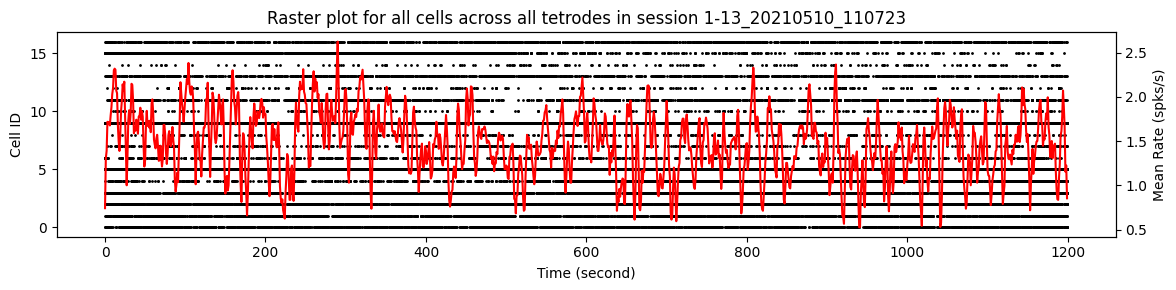

In [10]:
""" Raster plot for all cells and all tetrodes on one session """

sample = '1-13_20210510_110723'


# STEP #1: Get session of interest
with unit_of_work as uow:

    # query data arrays
    query = {
        "session_data_ref": {'schema_ref': 'session', 'data_name': sample},
    }
    sessions = view_query_factory(uow, query, exclude=["animal_position"])

    # query record metadata
    ses_record_query = {
        "schema_ref": "session",
        "data_name": sample
    }

    ses_record = uow.data.get(ses_record_query["schema_ref"], ses_record_query["data_name"])
    duration = ses_record["duration"]
    duration_units = ses_record["duration_unit"]

# STEP #2: Take different tetrode sessions and aggregate all cells
raster = []
# iterate through tetrode sessions
for session in sessions:
    spike_times_cluster = sessions[session].spike_times
    spike_times_cluster_indices = sessions[session].spike_labels
    # organize by cell
    for i in range(len(set(spike_times_cluster_indices[:,0].values))):
        # append single cell
        if i != 0:
            raster.append(spike_times_cluster.where(spike_times_cluster_indices == i, drop=True).values)

# STEP #3: Plot raster
fig = plt.figure(figsize=(12, 3))
ax = plt.subplot(1,1,1)
for i in range(len(raster)):
    ax.scatter(raster[i], i*np.ones(len(raster[i])), s=1, c='k')

# bin spike times to make mean firing rate trace
dur = int(float(duration))

#print dur and spike_time[-1]/max(spike_time)
# if dur is diffrent for different files

binned_raster = np.zeros((len(raster), dur))
for i in range(len(raster)):
    binned_raster[i] = np.histogram(raster[i], bins=dur)[0]
mean_firing_rate = binned_raster.mean(axis=0)
smoothed_mean_firing_rate = np.convolve(mean_firing_rate, np.ones(3)/10, mode='same')

twin_ax = ax.twinx()
twin_ax.plot(smoothed_mean_firing_rate, color='r')
twin_ax.set_ylabel("Mean Rate (spks/s)")

# ax.set_xlim(0, 200)
ax.set_xlabel("Time ({})".format(duration_units))
ax.set_ylabel("Cell ID")
ax.set_title("Raster plot for all cells across all tetrodes in session {}".format(ses_record["data_name"]))
fig.tight_layout()
plt.show()


None
waveforms1 length: 4
waveforms2 length: 4
[[  -1.   -6.   -4.    0.    3.    2.    0.   -1.    0.    4.   13.   20.
    24.   27.   27.   23.   20.   23.   30.   34.   31.   21.    7.   -2.
    -9.  -16.  -23.  -31.  -38.  -45.  -46.  -44.  -43.  -45.  -49.  -50.
   -48.  -46.  -44.  -40.  -29.  -14.    0.   12.   20.   24.   24.   24.
    26.   27.]
 [   6.   -6.  -13.  -15.  -19.  -25.  -28.  -17.    6.   34.   51.   47.
    19.  -24.  -68.  -91.  -90.  -68.  -37.  -13.   -5.   -8.  -11.  -13.
   -14.  -15.  -15.  -14.  -10.   -6.   -6.   -8.  -10.  -13.  -16.  -17.
   -14.   -9.   -6.   -4.    0.    5.   11.   15.   17.   20.   24.   27.
    25.   21.]
 [  -3.   -1.    4.    2.  -12.  -35.  -42.  -14.   44.   99.  111.   69.
    -5.  -76. -115. -120.  -99.  -62.  -27.   -8.   -5.  -11.  -16.  -18.
   -13.   -6.    0.    4.    9.   13.   14.   13.   10.    3.   -3.   -8.
   -11.   -9.   -1.    7.   12.   12.   11.    9.   10.   13.   16.   20.
    25.   33.]
 [ -15.  -16.  -12. 

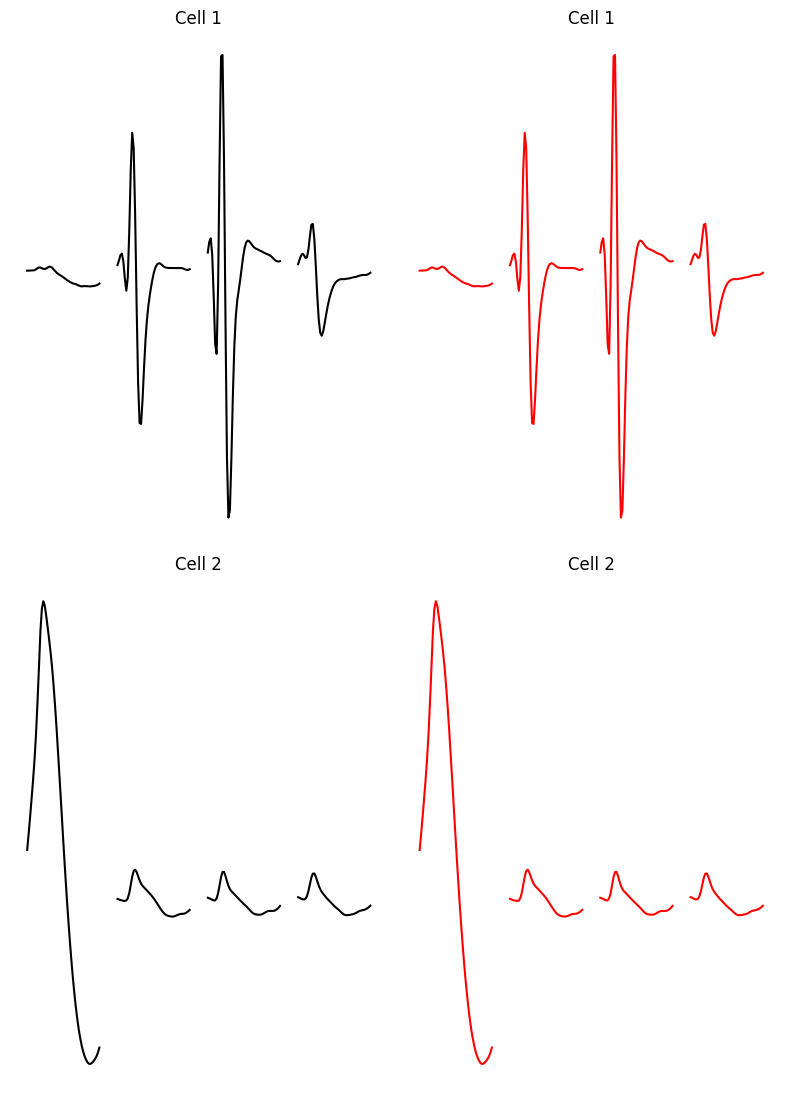

In [38]:
""" Cell waveforms for all cells in two sessions compared for one tetrode """

# STEP #1: Get first session of interest
with unit_of_work as uow:
    query = {
        "session_data_ref": {'schema_ref': 'session', 'data_name': '1-13_20210510_110723'},
        "probe_data_ref": {'schema_ref': 'probe', 'data_name': '1'}
    }
    sessions1 = view_query_factory(uow, query, exclude=["animal_position"])

    ses_record_query = {
        "schema_ref": "session",
        "data_name": "1-13_1_20210510_110723"
    }

    ses_record = uow.data.get(ses_record_query["schema_ref"], ses_record_query["data_name"])
    print(ses_record)
    # duration1 = ses_record["duration"]
    # duration_units = ses_record["duration_unit"]

# STEP #2: Get second session of interest
with unit_of_work as uow:
    query = {
        "session_data_ref": {'schema_ref': 'session', 'data_name': '1-13_20210510_110723'},
        "probe_data_ref": {'schema_ref': 'probe', 'data_name': '1'}
    }
    sessions2 = view_query_factory(uow, query, exclude=["animal_position"])

    ses_record_query = {
        "schema_ref": "session",
        "data_name": "1-13_20210510_110723"
    }

    ses_record = uow.data.get(ses_record_query["schema_ref"], ses_record_query["data_name"])
    # duration2 = ses_record["duration"]
    # duration_units = ses_record["duration_unit"]

# assert duration1 == duration2, "Sessions must have the same duration"

# STEP #3: Take different tetrode sessions and aggregate all cells
waveforms1 = []
# iterate through tetrode sessions
for session in sessions1:
    spike_waveforms = sessions1[session].tet_waveforms
    spike_times_cluster_indices = sessions1[session].spike_labels
    # organize by cell
    for i in range(len(set(spike_times_cluster_indices[:,0].values))):
        # append single cell
        if i != 0:
            waveforms1.append(spike_waveforms.where(spike_times_cluster_indices[:,0] == i, drop=True).values)

waveforms2 = []
# iterate through tetrode sessions
for session in sessions2:
    spike_waveforms = sessions2[session].tet_waveforms
    spike_times_cluster_indices = sessions2[session].spike_labels
    # organize by cell
    for i in range(len(set(spike_times_cluster_indices[:,0].values))):
        # append single cell
        if i != 0:
            waveforms2.append(spike_waveforms.where(spike_times_cluster_indices[:,0] == i, drop=True).values)

# STEP #3: Plot waveforms
fig = plt.figure(figsize=(8, 22))

min_len = min(len(waveforms1), len(waveforms2))
waveforms1 = waveforms1[:min_len]
waveforms2 = waveforms2[:min_len]
print(f"waveforms1 length: {len(waveforms1)}")
print(f"waveforms2 length: {len(waveforms2)}")
print(waveforms1[0][0])
print(waveforms2[0][0])


ccount = 1
for i in range(0, min_len, 2):
    ax1 = plt.subplot(min_len, 2, i + 1)
    ax2 = plt.subplot(min_len, 2, i + 2)

    for k in range(4):
        xpos = np.linspace(50*k + 10, 50*(k+1), 50)
        ax1.plot(xpos, np.mean(waveforms1[i][:,k,:], axis=0), label="Session 1", color='k')
        ax2.plot(xpos, np.mean(waveforms2[i][:,k,:], axis=0), label="Session 2", color='r')

        # remove xticks, yticks, labels and spines
        for ax in [ax1,ax2]:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)
            ax.spines['bottom'].set_visible(False)
            ax.spines['left'].set_visible(False)
            ax.set_title("Cell {}".format(ccount))

    ccount += 1

# fig.suptitle("Cell waveforms in session 1 and session 2", y=1)
fig.tight_layout()
plt.show()

In [ ]:
def extract_arena_size_from_shape(arena_record):
    """
    Custom helper function to extract arena size specifically as a tuple of
    (height, width). Also returns boolean tag to denote arena as cylinder
    or not. Both outputs are required as inputs to the ratemap functions.
    """
    shape = arena_record['arena_shape']
    unit_of_measure = arena_record['unit_of_measure']
    if shape == 'cylinder':
        diameter = float(arena_record['diameter'])
        if unit_of_measure == 'm':
            diameter *= 100
        arena_size = (diameter, diameter)
        isCylinder = True
    elif shape == 'rectangle':
        arena_height = float(arena_record['arena_height'])
        arena_width = float(arena_record['arena_width'])
        if unit_of_measure == 'm':
            arena_height *= 100
            arena_width *= 100
        arena_size = (arena_height, arena_width)
        isCylinder = False

    return arena_size, isCylinder

def flat_disk_mask(rate_map):
    masked_rate_map = disk_mask(rate_map)
    masked_rate_map.data[masked_rate_map.mask] = np.nan
    return  masked_rate_map.data

def disk_mask(matrix):
        y_segments, x_segments = matrix.shape

        y_center, x_center = (y_segments-1)/2, (x_segments-1)/2

        mask_r = min(x_segments, y_segments)/2

        mask_y,mask_x = np.ogrid[-y_center:y_segments-y_center, -x_center:x_segments-x_center]
        mask = mask_x**2 + mask_y**2 > mask_r**2

        masked_matrix = np.ma.array(matrix, mask=mask)

        return masked_matrix


In [ ]:


def _speed2D(x, y, t):
    """calculates an averaged/smoothed speed"""

    N = len(x)
    v = np.zeros((N, 1))

    for index in range(1, N-1):
        v[index] = np.sqrt((x[index + 1] - x[index - 1]) ** 2 + (y[index + 1] - y[index - 1]) ** 2) / (
        t[index + 1] - t[index - 1])

    v[0] = v[1]
    v[-1] = v[-2]

    return v


def _speed_bins(lower_speed: float, higher_speed: float, pos_v: np.ndarray,
               pos_x: np.ndarray, pos_y: np.ndarray, pos_t: np.ndarray) -> tuple:

    '''
        Selectively filters position values of subject travelling between
        specific speed limits.

        Params:
            lower_speed (float):
                Lower speed bound (cm/s)
            higher_speed (float):
                Higher speed bound (cm/s)
            pos_v (np.ndarray):
                Array holding speed values of subject
            pos_x, pos_y, pos_t (np.ndarray):
                X, Y coordinate tracking of subject and timestamps

        Returns:
            Tuple: new_pos_x, new_pos_y, new_pos_t
            --------
            new_pos_x, new_pos_y, new_pos_t (np.ndarray):
                speed filtered x,y coordinates and timestamps
    '''

    # Initialize empty array that will only be populated with speed values within
    # specified bounds
    choose_array = []

    # Iterate and select speeds
    for index, element in enumerate(pos_v):
        if element > lower_speed and element < higher_speed:
            choose_array.append(index)

    # construct new x,y and t arrays
    new_pos_x = np.asarray([ float(pos_x[i]) for i in choose_array])
    new_pos_y = np.asarray([ float(pos_y[i]) for i in choose_array])
    new_pos_t = np.asarray([ float(pos_t[i]) for i in choose_array])

    return new_pos_x, new_pos_y, new_pos_t



def _spike_positions(x, y, t, spike_times, speed_bounds):

    v = _speed2D(x, y, t)
    x, y, t = _speed_bins(speed_bounds[0], speed_bounds[1], v, x, y, t)

    cPost = np.copy(t)

    N = len(spike_times)
    spike_positions_x = np.zeros((N, 1))
    spike_positions_y = np.zeros_like(spike_positions_x)
    new_spike_times = np.zeros_like(spike_positions_x)
    count = -1 

    for index in range(N):

        tdiff = (t -spike_times[index])**2
        tdiff2 = (cPost-spike_times[index])**2
        m = np.amin(tdiff)
        ind = np.where(tdiff == m)[0]

        m2 = np.amin(tdiff2)
        #ind2 = np.where(tdiff2 == m2)[0]

        if m == m2:
            count += 1
            spike_positions_x[count] = x[ind[0]]
            spike_positions_y[count] = y[ind[0]]
            new_spike_times[count] = spike_times[index]

    spike_positions_x = spike_positions_x[:count + 1]
    spike_positions_y = spike_positions_y[:count + 1]
    new_spike_times = new_spike_times[:count + 1]

    return spike_positions_x.flatten(), spike_positions_y.flatten(), new_spike_times.flatten()


def get_ratemap(x, y, t, spike_times, arena_size, smoothing_factor, speed_bounds, interp_size=(64, 64), useMinMaxPos=False):
    spike_x, spike_y, _ = _spike_positions(x, y, t, spike_times, speed_bounds)
    occ_map_smoothed, occ_map_raw = _occupancy_map(x, y, t, smoothing_factor, arena_size, interp_size, useMinMaxPos)
    spike_map_smooth, spike_map_raw = _spike_map(x, y, arena_size, spike_x, spike_y, smoothing_factor, interp_size, useMinMaxPos)
    rate_map, rate_map_raw = _ratemap(occ_map_smoothed, occ_map_raw, spike_map_smooth, spike_map_raw)
    return rate_map, rate_map_raw

def _ratemap(occ_map_data, raw_occ, spike_map_data, spike_map_data_raw):
    # rate_map_raw = np.where(raw_occ<0.0001, 0, spike_map_data_raw/raw_occ)
    rate_map = np.where(occ_map_data<0.0001, 0, spike_map_data/occ_map_data)
    rate_map = rate_map/max(rate_map.flatten())

    return rate_map, _
   
def _spike_map(pos_x, pos_y, arena_size, spike_x, spike_y, smoothing_factor, interp_size=(64, 64), useMinMaxPos=False):
    kernlen = int(smoothing_factor * 8)
    std = int(0.2 * kernlen)

    if useMinMaxPos:
        min_x, max_x = np.min(pos_x), np.max(pos_x)
        min_y, max_y = np.min(pos_y), np.max(pos_y)
    else:
        min_x = [-arena_size[1]/2]
        max_x = [arena_size[1]/2] # width 
        min_y = [-arena_size[0]/2]
        max_y = [arena_size[0]/2] # height

    row_resize, column_resize = interp_size
    spike_map_raw = np.zeros((row_resize, column_resize))
    row_values = np.linspace(max_x, min_x, row_resize)
    column_values = np.linspace(min_y, max_y, column_resize)
    row_index = np.abs(row_values[:, np.newaxis] - spike_y).argmin(axis=0)
    column_index = np.abs(column_values[:, np.newaxis] - spike_x).argmin(axis=0)
    np.add.at(spike_map_raw, (row_index, column_index), np.ones_like(row_index))
    spike_map_smooth = cv2.filter2D(spike_map_raw, -1, _gkern(kernlen, std))
    spike_map_smooth = spike_map_smooth / np.max(spike_map_smooth)
    return spike_map_smooth, spike_map_raw

def _gkern(kernlen: int, std: int) -> np.ndarray:

    '''
        Returns a 2D Gaussian kernel array.

        Params:
            kernlen, std (int):
                Kernel length and standard deviation

        Returns:
            np.ndarray:
                gkern2d
    '''

    gkern1d = signal.windows.gaussian(kernlen, std=std).reshape(kernlen, 1)
    gkern2d = np.outer(gkern1d, gkern1d)
    return gkern2d

def _occupancy_map(x, y, t, smoothing_factor, arena_size, interp_size=(64,64), useMinMaxPos=False) -> np.ndarray:

    '''
        Computes the position, or occupancy map, which is a 2D numpy array
        enconding subjects position over entire experiment.

        Params:
            pos_x, pos_y and pos_t (np.ndarray):
                Arrays of the subjects x and y coordinates, as
                well as timestamp array.
            arena_size (tuple):
                Arena dimensions (width (x), height (y) in meters)
            resolution (float):
                Resolution of occupancy map (in meters)
            kernlen, std : kernel size and standard deviation (i.e 'spread') for convolutional smoothing
                of 2D map

            Returns:
                np.ndarray: occ_map_smoothed, occ_map_raw, coverage_map
    '''
    pos_x, pos_y, pos_t = x, y, t

    if useMinMaxPos:
        min_x = min(pos_x)
        max_x = max(pos_x)
        min_y = min(pos_y)
        max_y = max(pos_y)
    else:
        min_x = [-arena_size[1]/2]
        max_x = [arena_size[1]/2] # width 
        min_y = [-arena_size[0]/2]
        max_y = [arena_size[0]/2] # height


    row_resize, column_resize = interp_size

    # Initialize empty map
    occ_map_raw = np.zeros((row_resize,column_resize))
    coverage_map = np.zeros((row_resize,column_resize))
    row_values = np.linspace(max_y,min_y,row_resize)
    column_values = np.linspace(min_x,max_x,column_resize)

    # Generate the raw occupancy map
    for i in range(1, len(pos_t)):

        row_index = np.abs(row_values - pos_y[i]).argmin()
        column_index = np.abs(column_values - pos_x[i]).argmin()
        occ_map_raw[row_index][column_index] += pos_t[i] - pos_t[i-1]

    kernlen = int(smoothing_factor*8)
    std = int(0.2*kernlen)

    occ_map_normalized = occ_map_raw / pos_t[-1]
    occ_map_smoothed = cv2.filter2D(occ_map_normalized,-1,_gkern(kernlen,std))

    kernel = np.ones((2,2))

    occ_map_smoothed = occ_map_smoothed/max(occ_map_smoothed.flatten())

    return occ_map_smoothed, occ_map_raw


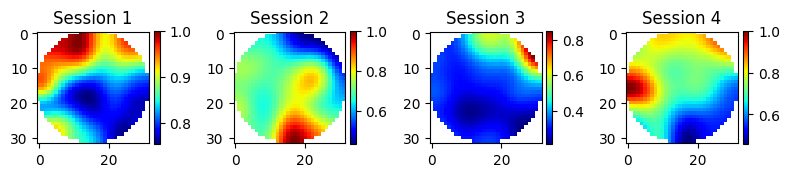

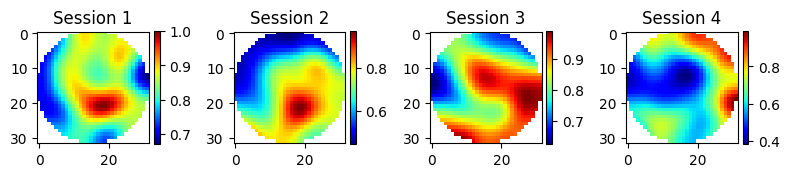

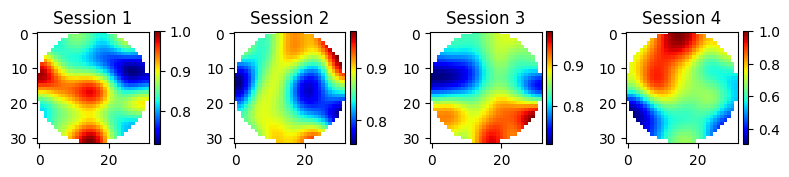

In [ ]:
""" Cell ratemap for one cell on one tetrode across all sessions """

for c in range(3):


    # STEP #1: Get all sessions for the cell of interested
    with unit_of_work as uow:
        query = {
            "probe_data_ref": {'schema_ref': 'probe', 'data_name': '1'},
        }

        sessions = view_query_factory(uow, query, cell_id=c+1, exclude=['animal_position'])

        ses_record_query = {
            "schema_ref": "session",
            "data_name": "1-13_20210510_110723"
        }

        ses_record = uow.data.get(ses_record_query["schema_ref"], ses_record_query["data_name"])
        duration = ses_record["duration"]
        duration_units = ses_record["duration_unit"]

        arena_record_query = {
            "schema_ref": "arena",
            "data_name": "Arena1_MEC"
        }

         

        session_position_query = {
            "schema_ref": "animal_position",
            "data_name": "1-13_20210510_110723"
        }

        session_position = uow.data.get(session_position_query["schema_ref"], session_position_query["data_name"])
    # STEP #2: Take different tetrode sessions and aggregate all cells
    ratemaps = []
    arena_size = None
    useMinMaxPos = True
    speed_bounds = (0, 100)
    interp_size = (32,32)
    smoothing_factor = 3
    x = session_position[:,0].to_numpy().squeeze()
    y = session_position[:,1].to_numpy().squeeze()
    t = session_position[:,2].to_numpy().squeeze()
    # iterate through tetrode sessions
    for session in sessions:
        spike_times = sessions[session].spike_times.to_numpy().squeeze()
        
        ratemap, _ = get_ratemap(x, y, t, spike_times, arena_size, smoothing_factor, speed_bounds, interp_size=interp_size, useMinMaxPos=useMinMaxPos)
        if isCylinder:
            ratemap = flat_disk_mask(ratemap)

        ratemaps.append(ratemap)

    # STEP #3: Plot ratemaps
    fig = plt.figure(figsize=(8,3))

    for i in range(len(ratemaps)):
        ax = plt.subplot(1,len(ratemaps), i+1)

        im = ax.imshow(ratemaps[i], cmap='jet')

        ax.set_title('Session {}'.format(str(i+1)))

        fig.colorbar(im, ax=ax,fraction=0.046, pad=0.04)

    fig.tight_layout()
    plt.show()



In [95]:
with unit_of_work as uow:
    query = {
        "schema_ref": "animal_position",
        "data_name": "1-13_20210510_110723"
    }
    session_position = uow.data.get(query["schema_ref"], query["data_name"])
    print(session_position.values.shape)
    posx = session_position[:,0].to_numpy().squeeze()
    posy = session_position[:,1].to_numpy().squeeze()
    post = session_position[:,2].to_numpy().squeeze()
    Fs_pos = float(session_position.attrs.get("sample_rate"))
    print(posx.shape, posy.shape, post.shape)
    save_figures_directory = pathlib.Path.cwd().parent / r"data" / r"output"

(57988, 3)
(57988,) (57988,) (57988,)


In [78]:
session_position

<xarray.DataArray 'animal_position__1-13_20210510_110723' (sample: 57988, xyt: 3)> Size: 1MB
array([[ 2.207131e-01, -1.439728e+01,  0.000000e+00],
       [ 5.602716e-01, -1.426995e+01,  2.000000e-02],
       [ 9.252971e-01, -1.410866e+01,  4.000000e-02],
       ...,
       [-2.113752e+01, -8.293718e+00,  1.199940e+03],
       [-2.106961e+01, -8.361630e+00,  1.199960e+03],
       [-2.101019e+01, -8.404075e+00,  1.199980e+03]])
Coordinates:
  * sample   (sample) float32 232kB 0.0 1.0 2.0 ... 5.799e+04 5.799e+04
  * xyt      (xyt) float32 12B 0.0 1.0 2.0
Attributes:
    sample_rate:           50.0
    session_data_ref:      {'schema_ref': 'session', 'data_name': '1-13_20210...
    animal_data_ref:       {'schema_ref': 'animal', 'data_name': '1-13'}
    has_file:              True
    schema_ref:            animal_position
    data_name:             1-13_20210510_110723
    recording_length:      20210510
    data_dimensions:       ['sample' 'xyt']
    dimension_of_measure:  [space]
    unit_of_measure:       cm

In [7]:
import numpy as np

def rgb2gray(rgb):
    r, g, b = rgb[:, :, 0], rgb[:, :, 1], rgb[:, :, 2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray
def speed2D(x, y, t):
    """calculates an averaged/smoothed speed"""

    N = len(x)
    v = np.zeros((N, 1))

    for index in range(1, N-1):
        v[index] = np.sqrt((x[index + 1] - x[index - 1]) ** 2 + (y[index + 1] - y[index - 1]) ** 2) / (
        t[index + 1] - t[index - 1])

    v[0] = v[1]
    v[-1] = v[-2]

    return v


def centreBox(posx, posy):
    """
    Computes the centre of the box defined by posx and posy.

    Parameters:
      posx: array-like, x-coordinates of the points.
      posy: array-like, y-coordinates of the points.

    Returns:
      list: [x, y] coordinates of the centre.
    """
    maxX = np.max(posx)
    minX = np.min(posx)
    maxY = np.max(posy)
    minY = np.min(posy)
    
    # Define the corners of the box
    NE = [maxX, maxY]
    NW = [minX, maxY]
    SW = [minX, minY]
    SE = [maxX, minY]
    
    centre = findCentre(NE, NW, SW, SE)
    return centre

def findCentre(NE, NW, SW, SE):
    """
    Calculates the centre of the box from the corner coordinates.
    The centre is the intersection of the diagonals.

    Parameters:
      NE, NW, SW, SE: list or array containing the [x, y] coordinates of the corners.
      
    Returns:
      list: [x, y] coordinates of the centre.
    """
    # Compute slopes for the diagonals
    a = (NE[1] - SW[1]) / (NE[0] - SW[0])  # slope for NE-SW diagonal
    b = (SE[1] - NW[1]) / (SE[0] - NW[0])  # slope for SE-NW diagonal
    c = SW[1]
    d = NW[1]
    x = (d - c + a * SW[0] - b * NW[0]) / (a - b)
    y = a * (x - SW[0]) + c
    return [x, y]

import numpy as np
from skimage.measure import label, regionprops

def bwarea_old(binary_image: np.ndarray) -> float:
    """
    Estimate the area of a binary object similar to MATLAB's bwarea.

    MATLAB's bwarea computes the area as:
        area = N + 0.5*P + 0.25*V
    where:
      - N is the number of object pixels,
      - P is the perimeter (here computed using regionprops),
      - V is the number of vertices (assumed 4 for a simple closed shape).
      
    For example, for a 40x40 filled square:
        N = 1600, P = 160, and V = 4,
        so area = 1600 + 0.5*160 + 0.25*4 = 1681.
    
    Parameters:
      binary_image: np.ndarray
          Input binary image (0/1 or bool).
    
    Returns:
      float: The estimated area.
    """
    # Ensure the image is boolean.
    bw = binary_image.astype(bool)
    
    # N: number of object pixels.
    N = np.sum(bw)
    
    # Compute perimeter using regionprops.
    # Note: regionprops uses a Crofton perimeter estimator.
    labeled = label(bw)
    props = regionprops(labeled)
    if len(props) > 0:
        P = props[0].perimeter
    else:
        P = 0
    
    # Assume V = 4 for a simple shape (e.g. a square).
    V = 4 if N > 0 else 0
    
    area = N + 0.5 * P + 0.25 * V
    return area


from skimage.measure import find_contours

def bwarea(binary_image: np.ndarray) -> float:
    """
    MATLAB's bwarea computes the area as:
        area = N + 0.5*P + 0.25*V
    where:
      - N is the number of object pixels,
      - P is the perimeter (computed along the actual object boundary),
      - V is the number of vertices (assumed 4 for a simple closed shape).
    
    Parameters:
      binary_image: np.ndarray
          Input binary image (0/1 or bool).
    
    Returns:
      float: The estimated area.
    """
    # Ensure the image is boolean.
    bw = binary_image.astype(bool)
    
    # N: number of object pixels.
    N = np.sum(bw)
    
    # Compute perimeter by extracting the contour at level 0.5,
    # which gives the actual continuous boundary length.
    contours = find_contours(bw.astype(float), level=0.5)
    if contours:
        # Use the longest contour if there are several.
        longest = max(contours, key=lambda c: c.shape[0])
        # Compute the Euclidean length along the contour.
        P = np.sum(np.sqrt(np.sum(np.diff(longest, axis=0)**2, axis=1)))
    else:
        P = 0
    
    # Assume V = 4 for a simple shape (e.g. a square).
    V = 4 if N > 0 else 0
    
    area = N + 0.5 * P + 0.25 * V
    return area


In [ ]:
from skimage.color import rgb2gray
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable


def plot_bin_metrics_heatmaps(bin_coverage_png, bin_distance_png, n_bins, bin_coverage, bin_distances):
    """    
    Parameters:
      dimensions: array-like, [xmin, xmax, ymin, ymax] of the arena.
      n_bins: int, number of bins per dimension (e.g. 4 for a 4x4 grid).
      bin_coverage: (n_bins x n_bins) array of percentage coverage values.
      bin_distances: (n_bins x n_bins) array of total distance values.
      output_path_prefix: str, prefix for the output file names.
    
    The function saves two PNG files:
      - {output_path_prefix}_coverage_heatmap.png
      - {output_path_prefix}_distance_heatmap.png
    """

    # --- Coverage Heatmap ---
    fig_cov, ax_cov = plt.subplots(figsize=(n_bins*2, n_bins*2))  # Adjust size based on number of bins
    # origin='lower' to have bin[0,0] at the bottom-left corner
    im_cov = ax_cov.imshow(bin_coverage, cmap='Greys', origin='lower')
    ax_cov.set_title("Bin Coverage Heatmap (%)")
    # Set tick labels to indicate bin positions (optional)
    ax_cov.set_xticks(np.arange(n_bins))
    ax_cov.set_yticks(np.arange(n_bins))
    ax_cov.set_xticklabels([f"{x+1:.1f}" for x in range(n_bins)])
    ax_cov.set_yticklabels([f"{y+1:.1f}" for y in range(n_bins)])
    divider = make_axes_locatable(ax_cov)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig_cov.colorbar(im_cov, cax=cax, label="Coverage")
    plt.tight_layout()
    fig_cov.savefig(bin_coverage_png, bbox_inches='tight', pad_inches=0)
    plt.close(fig_cov)

    # --- Distance Heatmap ---
    fig_dist, ax_dist = plt.subplots(figsize=(n_bins*2, n_bins*2))  # Adjust size based on number of bins
    im_dist = ax_dist.imshow(bin_distances, cmap='Greys', origin='lower')
    ax_dist.set_title("Bin Distance Heatmap (meters)")
    ax_dist.set_xticks(np.arange(n_bins))
    ax_dist.set_yticks(np.arange(n_bins))
    ax_dist.set_xticklabels([f"{x+1:.1f}" for x in range(n_bins)])
    ax_dist.set_yticklabels([f"{y+1:.1f}" for y in range(n_bins)])
    divider = make_axes_locatable(ax_dist)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    fig_dist.colorbar(im_dist, cax=cax, label="Distance")
    plt.tight_layout()
    fig_dist.savefig(bin_distance_png, bbox_inches='tight', pad_inches=0)
    plt.close(fig_dist)

    print(f"Heatmap images saved as:\n  Coverage: {bin_coverage_png}\n  Distance: {bin_distance_png}")



def plot_bin_metrics(dimensions, n_bins, bin_coverage, bin_distances, bin_metrics_png):
    """
    Create and save a plot of an arena divided into bins (grid) with text annotations
    in each bin showing the bin's coverage and distance metrics.
    
    Parameters:
      dimensions: array-like, [xmin, xmax, ymin, ymax] defining the arena.
      n_bins: int, number of bins along each axis (e.g., 4 for a 4x4 grid).
      bin_coverage: numpy array of shape (n_bins, n_bins) with percentage coverage per bin.
      bin_distances: numpy array of shape (n_bins, n_bins) with total distance per bin.
      output_path: str, the file path to save the plot.
    """
    xmin, xmax, ymin, ymax = dimensions
    # Define bin boundaries in coordinate space.
    x_bins = np.linspace(xmin, xmax, n_bins + 1)
    y_bins = np.linspace(ymin, ymax, n_bins + 1)
    
    # Create a figure and axes.
    fig, ax = plt.subplots(figsize=(20, 10.6066667), dpi=150)
    
    # Draw vertical grid lines.
    for x in x_bins:
        ax.axvline(x=x, color='k', lw=1)
    # Draw horizontal grid lines.
    for y in y_bins:
        ax.axhline(y=y, color='k', lw=1)
    
    # Annotate each bin with its coverage and distance.
    for i in range(n_bins):
        for j in range(n_bins):
            # Compute the center of the bin.
            cx = (x_bins[i] + x_bins[i+1]) / 2
            cy = (y_bins[j] + y_bins[j+1]) / 2
            # Format the text: coverage (in %) and distance.
            text = f"Coverage: {bin_coverage[j, i]:.1f}%\nDistance: {bin_distances[j, i]:.2f}"
            ax.text(cx, cy, text, ha='center', va='center', fontsize=12, color='black')
    
    # Set the axis limits to the arena dimensions.
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_aspect('equal', adjustable='box')
    
    # Optionally hide the axis.
    ax.axis('off')
    
    # Adjust layout and save the figure.
    plt.tight_layout()
    plt.savefig(bin_metrics_png, bbox_inches='tight', pad_inches=0)
    plt.close(fig)
    print(f"Plot saved as {bin_metrics_png}")


def attribute_segment_to_bins(x1, y1, x2, y2, x_bins, y_bins):
    """
    Given a segment from (x1, y1) to (x2, y2) and grid boundaries (x_bins, y_bins),
    return a dictionary where keys are (bin_i, bin_j) and values are the length of
    the segment attributed to that bin.
    
    Parameters:
      x1, y1, x2, y2: float
          Endpoints of the segment.
      x_bins: 1D array of bin boundaries in x.
      y_bins: 1D array of bin boundaries in y.
    
    Returns:
      contributions: dict with keys (i,j) and values = subsegment length.
    """
    dx = x2 - x1
    dy = y2 - y1
    seg_length = np.sqrt(dx**2 + dy**2)
    if seg_length == 0:
        return {}
    
    # Start with t=0 and t=1
    t_vals = [0.0, 1.0]
    
    # Find t where the line crosses vertical boundaries (ignore the extreme boundaries)
    for X in x_bins[1:-1]:
        if dx != 0:
            t = (X - x1) / dx
            if 0 < t < 1:
                t_vals.append(t)
    
    # Find t where the line crosses horizontal boundaries
    for Y in y_bins[1:-1]:
        if dy != 0:
            t = (Y - y1) / dy
            if 0 < t < 1:
                t_vals.append(t)
    
    # Remove duplicates and sort
    t_vals = np.unique(t_vals)
    t_vals.sort()
    
    contributions = {}
    # For each subsegment, compute its midpoint and attribute its length to the appropriate bin.
    for i in range(len(t_vals) - 1):
        t_start = t_vals[i]
        t_end = t_vals[i+1]
        t_mid = (t_start + t_end) / 2.0
        xm = x1 + dx * t_mid
        ym = y1 + dy * t_mid
        # Determine which bin this midpoint falls into.
        # np.digitize returns indices starting at 1, so subtract 1.
        bin_i = np.digitize(xm, x_bins) - 1
        bin_j = np.digitize(ym, y_bins) - 1
        subseg_length = seg_length * (t_end - t_start)
        contributions[(bin_i, bin_j)] = contributions.get((bin_i, bin_j), 0) + subseg_length
    return contributions

def compute_bin_metrics(posx, posy, BWdfill_total, BWdfill_filled, dimensions, image_resolution, n_bins=4):
    """
    Divide the arena (square) into an n_bins x n_bins grid and compute for each bin:
      - percentage coverage: fraction (0-100%) of the bin area in the binary mask that is "filled"
      - total distance: sum of Euclidean distances for segments, proportionally attributed to bins if they cross boundaries.
    
    Parameters:
      posx, posy: 1D numpy arrays (in arena coordinate space) for animal positions.
      BWdfill_total: 2D binary numpy array representing total area (e.g., arena border mask).
      BWdfill_filled: 2D binary numpy array representing the filled area (e.g., coverage mask).
      dimensions: array-like, [xmin, xmax, ymin, ymax] of the arena.
      image_resolution: tuple (height, width) in pixels of the BWdfill image.
      n_bins: number of bins per dimension (default 4 for a 4x4 grid).
    
    Returns:
      coverage: a (n_bins x n_bins) numpy array with percentage coverage per bin.
      distance: a (n_bins x n_bins) numpy array with total distance traveled in each bin.
    """
    H, W = image_resolution
    xmin, xmax, ymin, ymax = dimensions
    dx = xmax - xmin
    dy = ymax - ymin
    
    # Create bin boundaries in coordinate space:
    x_bins = np.linspace(xmin, xmax, n_bins + 1)
    y_bins = np.linspace(ymin, ymax, n_bins + 1)
    
    # Initialize output arrays.
    coverage = np.zeros((n_bins, n_bins))
    distance = np.zeros((n_bins, n_bins))
    
    # --- Compute coverage per bin ---
    for i in range(n_bins):
        for j in range(n_bins):
            # Bin boundaries in coordinate space:
            x0, x1 = x_bins[i], x_bins[i+1]
            y0, y1 = y_bins[j], y_bins[j+1]
            
            # Map these boundaries to pixel coordinates:
            col0 = int(np.floor(((x0 - xmin) / dx) * (W - 1)))
            col1 = int(np.ceil(((x1 - xmin) / dx) * (W - 1)))
            row0 = int(np.floor(((y0 - ymin) / dy) * (H - 1)))
            row1 = int(np.ceil(((y1 - ymin) / dy) * (H - 1)))
            
            bin_total_area = bwarea(BWdfill_total[row0:row1, col0:col1])
            bin_total_filled = bwarea(BWdfill_filled[row0:row1, col0:col1])
            if bin_total_area > 0:
                bin_percent = (bin_total_filled / bin_total_area) * 100
            else:
                bin_percent = 0
            coverage[j, i] = bin_percent  # note: j for row, i for column

    # --- Compute total distance per bin with proportional attribution ---
    # Ensure posx, posy are 1D arrays.
    posx = posx.flatten()
    posy = posy.flatten()
    for k in range(len(posx) - 1):
        x1_pt, y1_pt = posx[k], posy[k]
        x2_pt, y2_pt = posx[k+1], posy[k+1]
        # Get contributions for the segment.
        contrib = attribute_segment_to_bins(x1_pt, y1_pt, x2_pt, y2_pt, x_bins, y_bins)
        for (i, j), d in contrib.items():
            # Check index bounds
            if 0 <= i < n_bins and 0 <= j < n_bins:
                # Convert to meters if positions are in centimeters (adjust divisor as needed)
                distance[j, i] += d / 100.0
    
    return coverage, distance


In [137]:
## imports ##

import importlib.util
import sys
from scipy import ndimage
import numpy as np
import matplotlib.pyplot as plt
import imageio
from skimage import color
import skimage
import matplotlib
PROJECT_PATH = '/Users/Anurag/Downloads/NeuroLab/NSK-isolated'
sys.path.append(PROJECT_PATH)
print(PROJECT_PATH)
module_name = "animal_performance"


# Define file path
file_path = "/Users/Anurag/Downloads/NeuroLab/NSK-isolated/scripts/batch_map/animal_performance.py"

# Load module
spec = importlib.util.spec_from_file_location(module_name, file_path)
animal_performance = importlib.util.module_from_spec(spec)
sys.modules[module_name] = animal_performance
spec.loader.exec_module(animal_performance)

def is_circle(points, corners):
    """
    Determines if the arena is circular based on the points and corners.

    Parameters:
      points: np.ndarray
          Array of points (x, y) coordinates.
      corners: np.ndarray
          Array of corners (x, y) coordinates.

    Returns:
      bool: True if the arena is circular, False otherwise.
    """
    circle_bool = []
    for corner in range(4):
        if corner == 0:  # NE corner
            bool_val = (points[:, 0] >= 0) * (points[:, 1] >= 0)
        elif corner == 1:  # NW Corner
            bool_val = (points[:, 0] < 0) * (points[:, 1] >= 0)
        elif corner == 2:  # SW Corner
            bool_val = (points[:, 0] < 0) * (points[:, 1] < 0)
        else:  # SE corner
            bool_val = (points[:, 0] > 0) * (points[:, 1] < 0)
        
        current_points = points[bool_val, :]
        circle_bool.append(np.sum((current_points[:, 0] > corners[corner, 0]) * 
                                (current_points[:, 1] > corners[corner, 1])))

    return sum(circle_bool) < 1



## main function ##

def get_animal_performance(session_data, root_path, settings_dict):
    
    posx = session_data[:,0].to_numpy().squeeze()
    posy = session_data[:,1].to_numpy().squeeze()
    post = session_data[:,2].to_numpy().squeeze()
    print(posx.shape, posy.shape, post.shape)
    save_figures_directory = pathlib.Path.cwd().parent / r"data" / r"output"
    # plot_linewidth = 5.334
    plot_linewidth = 10.5
    # plot_linewidth = 10000 ## avg mice len is 2.25 according to the ppm calcluations
    if len(posx) == 0:
        print('There are no valid positions (all NaNs)')
    posx = posx.reshape(-1, 1)
    posy = posy.reshape(-1, 1)
    

    print(session_data)
    print('calculating the total distance for the .pos file: %s ' % session_data.attrs.get('session_data_ref')["data_name"])

    diffX = np.diff(posx, axis=0)
    diffY = np.diff(posy, axis=0)
    dist_sample = np.sqrt((diffX ** 2) + (diffY ** 2))
    total_distance = np.sum(dist_sample)
    total_distance = total_distance/100  # convert to meters
    print('Calculating coverage!')
    points = np.hstack((posx.reshape((len(posx), 1)), posy.reshape((len(posy), 1))))
    dimensions = np.array([np.amin(posx), np.amax(posx), np.amin(posy), np.amax(posy)])

    arena_fig = plt.figure(figsize=(20, 10.6066667), dpi=150)
    ax = arena_fig.add_subplot(111)
    ax.plot(posx, posy, 'r-', lw=plot_linewidth)
    ax.axis('off')
    

    bin_x = np.linspace(np.amin(posx), np.amax(posx), 11)
    bin_y = np.linspace(np.amin(posy), np.amax(posy), 11)
    corners = np.array([[bin_x[-2], bin_y[-2]], [bin_x[1], bin_y[-2]], 
                        [bin_x[1], bin_y[1]], [bin_x[-2], bin_y[1]]])
    
    plot_corners = False
    if plot_corners:
        # plots to see the test if it is a square or cirlce. I essentially
        # determine if there is data at the corners of the arena
        fig_corners = plt.figure()
        ax_corners = fig_corners.add_subplot(111)
        ax_corners.plot(posx, posy, 'r-')
        ax_corners.plot(corners[0:2, 0], corners[0:2, 1], 'g')
        ax_corners.plot(corners[1:3, 0], corners[1:3, 1], 'g')
        ax_corners.plot(corners[[0, 3], 0], corners[[0, 3], 1], 'g')
        ax_corners.plot(corners[[2, 3], 0], corners[[2, 3], 1], 'g')
        ax_corners.set_title('Corners of the bins')

    circle_bool = is_circle(points, corners)
    coverage_figure = plt.figure(figsize=(20, 10.6066667), dpi=150)
    ax_coverage = coverage_figure.add_subplot(111)
    if not circle_bool:
        print('Arena detected as being square')

        # Define bins for x and y
        bins = np.linspace(np.amin(posx), np.amax(posx), 20)
        bin_edges = np.hstack((bins[:-1].reshape((-1, 1)), bins[1:].reshape((-1, 1))))

        # Define rectangle for square arena
        rectangle_points = np.array([
            [np.amin(posx), np.amax(posy)],  # NW
            [np.amax(posx), np.amax(posy)],  # NE
            [np.amax(posx), np.amin(posy)],  # SE
            [np.amin(posx), np.amin(posy)],  # SW
            [np.amin(posx), np.amax(posy)]   # NW (closing the loop)
        ])

        border = ax_coverage.plot(rectangle_points[:, 0], rectangle_points[:, 1], 'b', lw=plot_linewidth / 10)
        # Plot arena boundaries
        ax_coverage.plot(rectangle_points[:, 0], rectangle_points[:, 1], 'b', lw=plot_linewidth / 10)
        ax_coverage.plot(posx, posy, 'r-', lw=plot_linewidth)

        # Set axis limits
        ax_coverage.set_xlim([min([dimensions[0], np.amin(rectangle_points[:, 0])]) - 0.5,
                                max([dimensions[1], np.amax(rectangle_points[:, 0])]) + 0.5])
        ax_coverage.set_ylim([min([dimensions[2], np.amin(rectangle_points[:, 1])]) - 0.5,
                                max([dimensions[3], np.amax(rectangle_points[:, 1])]) + 0.5])
        ax.set_xlim([min([dimensions[0], np.amin(rectangle_points[:, 0])]) - 0.5,
                        max([dimensions[1], np.amax(rectangle_points[:, 0])]) + 0.5])
        ax.set_ylim([min([dimensions[2], np.amin(rectangle_points[:, 1])]) - 0.5,
                                max([dimensions[3], np.amax(rectangle_points[:, 1])]) + 0.5])
                

    else:
        print('Arena detected as being circular')

        bins = np.linspace(np.amin(posx), np.amax(posx), 50)
        bin_edges = np.hstack((bins[:-1].reshape((-1, 1)), bins[1:].reshape((-1, 1))))

        # Compute radii
        radii = np.array([np.abs(np.amin(posx)), np.amax(posx), np.abs(np.amin(posy)), np.amax(posy)])
        for bin_value in range(len(bin_edges)):
            bin_bool = (posx >= bin_edges[bin_value, 0]) * (posx < bin_edges[bin_value, 1])
            if sum(bin_bool) == 0:
                continue

            posx_bin = posx[bin_bool]
            posy_bin = posy[bin_bool]
            max_val = np.amax(posy_bin)
            max_i = np.where(posy_bin == max_val)[0][0]
            min_val = np.amin(posy_bin)
            min_i = np.where(posy_bin == min_val)[0][0]
            append_radii = np.array([np.sqrt(max_val ** 2 + posx_bin[max_i] ** 2),
                                    np.sqrt(min_val ** 2 + posx_bin[min_i] ** 2)])
            radii = np.concatenate((radii, append_radii))

        # Generate circle for circular arena
        step = 0.001
        ang = np.arange(np.round((4 * np.pi + step) / step)) / (1 / step)
        xp, yp = animal_performance.circle_vals(0, 0, 2 * np.amax(radii), ang)
        border = ax_coverage.plot(xp, yp, 'b', lw=plot_linewidth / 10)
        ax_coverage.plot(xp, yp, 'b', lw=plot_linewidth / 10)
        ax_coverage.plot(posx, posy, 'r-', lw=plot_linewidth)
        

        ax_coverage.set_xlim([min([dimensions[0], np.amin(xp)]) - 0.5,
                                max([dimensions[1], np.amax(xp)]) + 0.5])
        ax_coverage.set_ylim([min([dimensions[2], np.amin(yp)]) - 0.5,
                                max([dimensions[3], np.amax(yp)]) + 0.5])
        ax.set_xlim([min([dimensions[0], np.amin(xp)]) - 0.5,
                                max([dimensions[1], np.amax(xp)]) + 0.5])
        ax.set_ylim([min([dimensions[2], np.amin(yp)]) - 0.5,
                                max([dimensions[3], np.amax(yp)]) + 0.5])
        

    # Save figure to file
    # save_path = "arena_plot.png"
    cover_png_total = os.path.join(save_figures_directory, '%s_total.png' % session_data.attrs.get('session_data_ref')["data_name"])
    ax_coverage.axis('off')
    # plt.subplots_adjust(left=0, right=1, top=1, bottom=0)  # Remove margins
    coverage_figure.patch.set_facecolor('white')
    # coverage_figure.savefig(cover_png_total, bbox_inches='tight', pad_inches=0, transparent=False)
    # coverage_figure.savefig(cover_png_total, dpi=150, pad_inches=0, transparent=False)
    coverage_figure.savefig(cover_png_total, dpi=150, pad_inches=0)

    # plt.savefig(save_path, bbox_inches='tight', dpi=300)
    print(f"Figure saved as {cover_png_total}")

    # Show the figure
    # plt.show()

    RGBA = imageio.imread(cover_png_total)
    RGB = color.rgba2rgb(RGBA)
    I = rgb2gray(RGB)
    I = np.round(I).astype('int32')

    BWs_x = ndimage.sobel(I, 0)  # horizontal derivative
    BWs_y = ndimage.sobel(I, 1)  # vertical derivative
    BWs = np.hypot(BWs_x, BWs_y)  # magnitude
    BWs *= 255.0 / np.amax(BWs) 
    BWsdil = ndimage.morphology.binary_dilation(BWs)
    BWdfill = ndimage.morphology.binary_fill_holes(BWsdil)
    total_area = bwarea(BWdfill)
    BWdfill_total = BWdfill.copy()
    border[0].remove()  # remove border 
    cover_png = os.path.join(save_figures_directory, '%s_coverage.png' % session_data.attrs.get('session_data_ref')["data_name"])
    # coverage_figure.savefig(cover_png, bbox_inches='tight')  # save figure without border
    ax.axis('off')
    arena_fig.savefig(cover_png, dpi=150, pad_inches=0, transparent=False)

    # reading in the positions without the arena trace
    RGBA = imageio.imread(cover_png)
    try:
        RGB = color.rgba2rgb(RGBA)
    except ValueError:
        RGB = RGBA
    I = rgb2gray(RGB)
    I = np.round(I).astype('int32')
    if np.amax(I) <= 1:
        # then the image was saved from numpy
        BWdfill = I < 1
    else:
        BWdfill = I < 255
    # finding the contours of the path so we can find the area

    coverage_fill_figure = plt.figure()
    ax_coverage_fill = coverage_fill_figure.add_subplot(111)
    # mng = plt.get_current_fig_manager()
    ax_coverage_fill.imshow(BWdfill, cmap=plt.cm.gray)
    plt.title("BWdfill2")
    filled_png = os.path.join(save_figures_directory, '%s_filled.png' % session_data.attrs.get('session_data_ref')["data_name"])
    coverage_fill_figure.savefig(filled_png, bbox_inches='tight')
    total_filled = bwarea(BWdfill)
    BWdfill_filled = BWdfill.copy()
    image_resolution = (1591, 3000)
    n_bins = 4
    bin_coverage, bin_distances = compute_bin_metrics(posx, posy, BWdfill_total,BWdfill_filled, dimensions, image_resolution, n_bins)
    bin_coverage_png = os.path.join(save_figures_directory, '%s_bin_coverage_heatmap.png' % session_data.attrs.get('session_data_ref')["data_name"])
    bin_distance_png = os.path.join(save_figures_directory, '%s_bin_distance_heatmap.png' % session_data.attrs.get('session_data_ref')["data_name"])
    bin_metrics_png = os.path.join(save_figures_directory, '%s_bin_metrics.png' % session_data.attrs.get('session_data_ref')["data_name"])
    plot_bin_metrics_heatmaps(bin_coverage_png, bin_distance_png, n_bins, bin_coverage, bin_distances)
    plot_bin_metrics(dimensions, n_bins, bin_coverage, bin_distances, bin_metrics_png)
    print('total area: %f' % total_area)
    print('total filled: %f' % total_filled)
    percent = (total_filled / total_area) * 100
    print('Coverage(Percent): %f' % (100*total_filled/total_area))

    speed = speed2D(posx, posy, post)

    print(f"total_area: {total_area}")
    print(f"total_filled: {total_filled}")
    print(f"percent: {percent}")
    print(f"total_distance: {total_distance}")
    print(f"speed: {speed}")

    return total_area, total_filled, percent, total_distance, speed, bin_distances, bin_coverage


/Users/Anurag/Downloads/NeuroLab/NSK-isolated


In [138]:
import os
import pandas as pd
import datetime
import tkinter as tk
from tkinter import filedialog
import time
from openpyxl.utils.cell import get_column_letter

# Example function signature for refactored code
def batch_map_via_queries(uow, session_queries, settings_dict, save_dir):


    csv_header = settings_dict['header']
    run_number = 1
    root_path = os.path.join(save_dir, 'Animal_Performance_Results')
    while os.path.isdir(root_path + str(run_number)):
        run_number += 1
    root_path += str(run_number)
    os.mkdir(root_path)

    # Initialize empty dataframe with columns
    headers = [k for k, v in csv_header.items() if v]
    headers_dict = dict()
    for i, header in enumerate(headers):
        headers_dict[header] = get_column_letter(i+1) ## Excel function to get let's say Column A, B, C etc.

    file_name = os.path.join(root_path, "ap_parameters.txt")
    with open(file_name, 'w') as f:
        for ky in settings_dict:
            f.write(str(ky) + ' is: ')
            f.write(str(settings_dict[ky]) + '\n')
        f.close()

    df_summary = pd.DataFrame(columns=headers)

    visited = []

    for session_query in session_queries:

        session_name = session_query['data_name']
        print('data name', session_name)
        if session_name in visited:
            continue

        visited.append(session_name)

        session_data = uow.data.get(session_query['schema_ref'], session_query['data_name'])

        ap_stats = get_animal_performance(session_data, root_path, settings_dict)
        (total_area, total_filled, percent, total_distance, speed, bin_distances, bin_coverage) = ap_stats

        # Build the overall performance row.
        row = {
            "signature": session_name,
            "total_area": total_area,
            "total_filled": total_filled,
            "coverage": percent,
            "total_distance": total_distance,
            "min_speed": np.min(speed),
            "max_speed": np.max(speed),
            "mean_speed": np.mean(speed),
            "median_speed": np.median(speed)
        }
        centre_distance = 0.0
        centre_coverage = 0.0
        boundaries_distance = 0.0
        boundaries_coverage = 0.0
        num_bins = bin_distances.shape[0]  # should be 4
        for i in range(num_bins):
            for j in range(num_bins):
                row[f"bin_distance_r{i+1}_c{j+1}"] = bin_distances[i, j]
                row[f"bin_coverage_r{i+1}_c{j+1}"] = bin_coverage[i, j]
                if i in [1, 2] and j in [1, 2]:
                    centre_distance += bin_distances[i, j]
                    centre_coverage += bin_coverage[i, j]
                else:
                    boundaries_distance += bin_distances[i, j]
                    boundaries_coverage += bin_coverage[i, j]

        centre_coverage /= 4.0 ## average over the 4 centre bins
        boundaries_coverage /= 12.0 ## average over the 12 boundary bins

        row["centre_distance"] = centre_distance
        row["centre_coverage"] = centre_coverage
        row["boundaries_distance"] = boundaries_distance
        row["boundaries_coverage"] = boundaries_coverage

        df_summary.loc[len(df_summary)] = row

    # Save dataframe to CSV
    summary_csv_path = os.path.join(root_path, 'performance_summary.csv')
    df_summary.to_csv(summary_csv_path, index=False)

    print(f'Summary data saved to {summary_csv_path}')


data name 1-13_20210510_163938
(58587,) (58587,) (58587,)
<xarray.DataArray 'animal_position__1-13_20210510_163938' (sample: 58587, xyt: 3)> Size: 1MB
[175761 values with dtype=float64]
Coordinates:
  * sample   (sample) float32 234kB 0.0 1.0 2.0 ... 5.858e+04 5.859e+04
  * xyt      (xyt) float32 12B 0.0 1.0 2.0
Attributes:
    sample_rate:           50.0
    session_data_ref:      {'schema_ref': 'session', 'data_name': '1-13_20210...
    animal_data_ref:       {'schema_ref': 'animal', 'data_name': '1-13'}
    has_file:              True
    schema_ref:            animal_position
    data_name:             1-13_20210510_163938
    recording_length:      20210510
    data_dimensions:       ['sample' 'xyt']
    dimension_of_measure:  [space]
    unit_of_measure:       cm
calculating the total distance for the .pos file: 1-13_20210510_163938 
Calculating coverage!
Arena detected as being square
Figure saved as /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210510_163938_t

/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:206: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  RGBA = imageio.imread(cover_png_total)
/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:215: DeprecationWarning: Please import `binary_dilation` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  BWsdil = ndimage.morphology.binary_dilation(BWs)
/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:216: DeprecationWarning: Please import `binary_fill_holes` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  BWdfill = ndimage.morphology.binary_fill_holes(B

Heatmap images saved as:
  Coverage: /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210510_163938_bin_coverage_heatmap.png
  Distance: /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210510_163938_bin_distance_heatmap.png
Plot saved as /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210510_163938_bin_metrics.png
total area: 2771899.785317
total filled: 2421909.024133
Coverage(Percent): 87.373614
total_area: 2771899.7853172678
total_filled: 2421909.0241328105
percent: 87.37361418914364
total_distance: 91.52114825077065
speed: [[4.03225806]
 [4.03225806]
 [3.82592453]
 ...
 [0.        ]
 [0.        ]
 [0.        ]]
data name 1-13_20210511_104628
(58971,) (58971,) (58971,)
<xarray.DataArray 'animal_position__1-13_20210511_104628' (sample: 58971, xyt: 3)> Size: 1MB
[176913 values with dtype=float64]
Coordinates:
  * sample   (sample) float32 236kB 0.0 1.0 2.0 ... 5.897e+04 5.897e+04
  * xyt      (xyt) float32 12B 0.0 1.0 2.0
Attributes:
    

/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:206: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  RGBA = imageio.imread(cover_png_total)
/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:215: DeprecationWarning: Please import `binary_dilation` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  BWsdil = ndimage.morphology.binary_dilation(BWs)
/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:216: DeprecationWarning: Please import `binary_fill_holes` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  BWdfill = ndimage.morphology.binary_fill_holes(B

Heatmap images saved as:
  Coverage: /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210511_104628_bin_coverage_heatmap.png
  Distance: /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210511_104628_bin_distance_heatmap.png
Plot saved as /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210511_104628_bin_metrics.png
total area: 2771628.462987
total filled: 2559175.063671
Coverage(Percent): 92.334709
total_area: 2771628.4629867976
total_filled: 2559175.06367133
percent: 92.33470856023318
total_distance: 118.77460928385842
speed: [[6.66397219]
 [6.66397219]
 [7.52722744]
 ...
 [0.        ]
 [0.        ]
 [0.        ]]
data name 1-13_20210511_154137
(57994,) (57994,) (57994,)
<xarray.DataArray 'animal_position__1-13_20210511_154137' (sample: 57994, xyt: 3)> Size: 1MB
[173982 values with dtype=float64]
Coordinates:
  * sample   (sample) float32 232kB 0.0 1.0 2.0 ... 5.799e+04 5.799e+04
  * xyt      (xyt) float32 12B 0.0 1.0 2.0
Attributes:
    s

/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:206: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  RGBA = imageio.imread(cover_png_total)
/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:215: DeprecationWarning: Please import `binary_dilation` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  BWsdil = ndimage.morphology.binary_dilation(BWs)
/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:216: DeprecationWarning: Please import `binary_fill_holes` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  BWdfill = ndimage.morphology.binary_fill_holes(B

Heatmap images saved as:
  Coverage: /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210511_154137_bin_coverage_heatmap.png
  Distance: /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210511_154137_bin_distance_heatmap.png
Plot saved as /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210511_154137_bin_metrics.png
total area: 2770998.424928
total filled: 2491948.129689
Coverage(Percent): 89.929612
total_area: 2770998.4249275746
total_filled: 2491948.129688508
percent: 89.92961191429187
total_distance: 104.70912885247338
speed: [[2.47493714]
 [2.47493714]
 [2.47493714]
 ...
 [0.        ]
 [0.        ]
 [0.        ]]
data name 1-13_20210510_110723
(57988,) (57988,) (57988,)
<xarray.DataArray 'animal_position__1-13_20210510_110723' (sample: 57988, xyt: 3)> Size: 1MB
[173964 values with dtype=float64]
Coordinates:
  * sample   (sample) float32 232kB 0.0 1.0 2.0 ... 5.799e+04 5.799e+04
  * xyt      (xyt) float32 12B 0.0 1.0 2.0
Attributes:
    

/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:206: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  RGBA = imageio.imread(cover_png_total)
/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:215: DeprecationWarning: Please import `binary_dilation` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  BWsdil = ndimage.morphology.binary_dilation(BWs)
/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/564025109.py:216: DeprecationWarning: Please import `binary_fill_holes` from the `scipy.ndimage` namespace; the `scipy.ndimage.morphology` namespace is deprecated and will be removed in SciPy 2.0.0.
  BWdfill = ndimage.morphology.binary_fill_holes(B

Heatmap images saved as:
  Coverage: /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210510_110723_bin_coverage_heatmap.png
  Distance: /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210510_110723_bin_distance_heatmap.png
Plot saved as /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210510_110723_bin_metrics.png
total area: 2769952.152850
total filled: 2550569.505843
Coverage(Percent): 92.079912
total_area: 2769952.152849636
total_filled: 2550569.5058428473
percent: 92.07991203815217
total_distance: 115.91868591811851
speed: [[19.03521307]
 [19.03521307]
 [20.62180692]
 ...
 [ 4.21252828]
 [ 4.21252828]
 [ 4.21252828]]
Summary data saved to /Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/Animal_Performance_Results11/performance_summary.csv


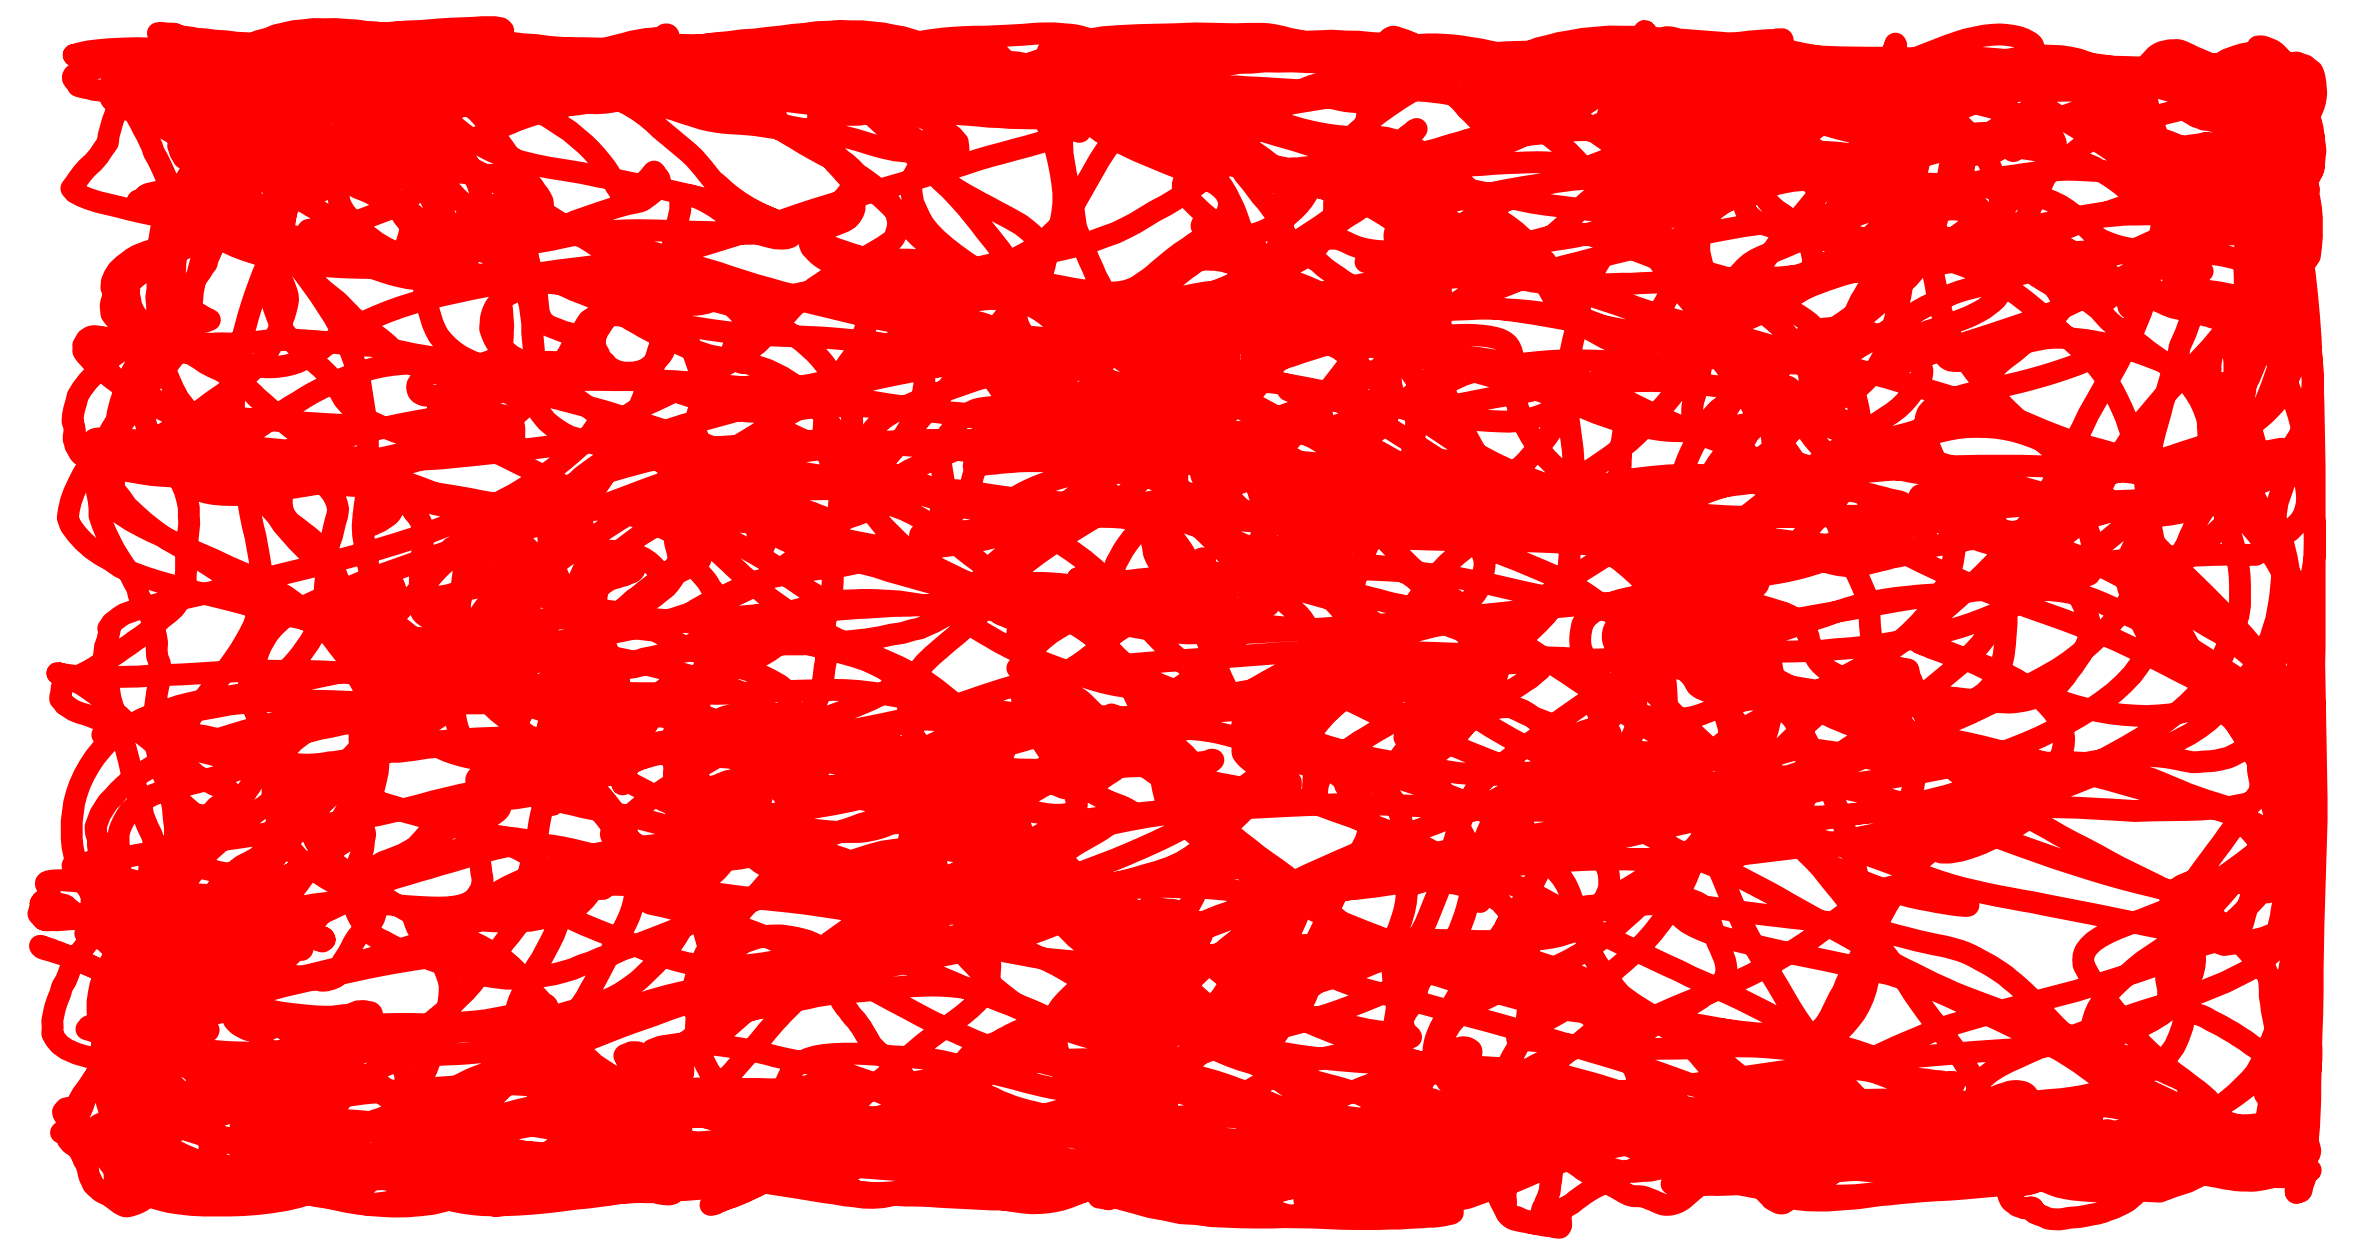

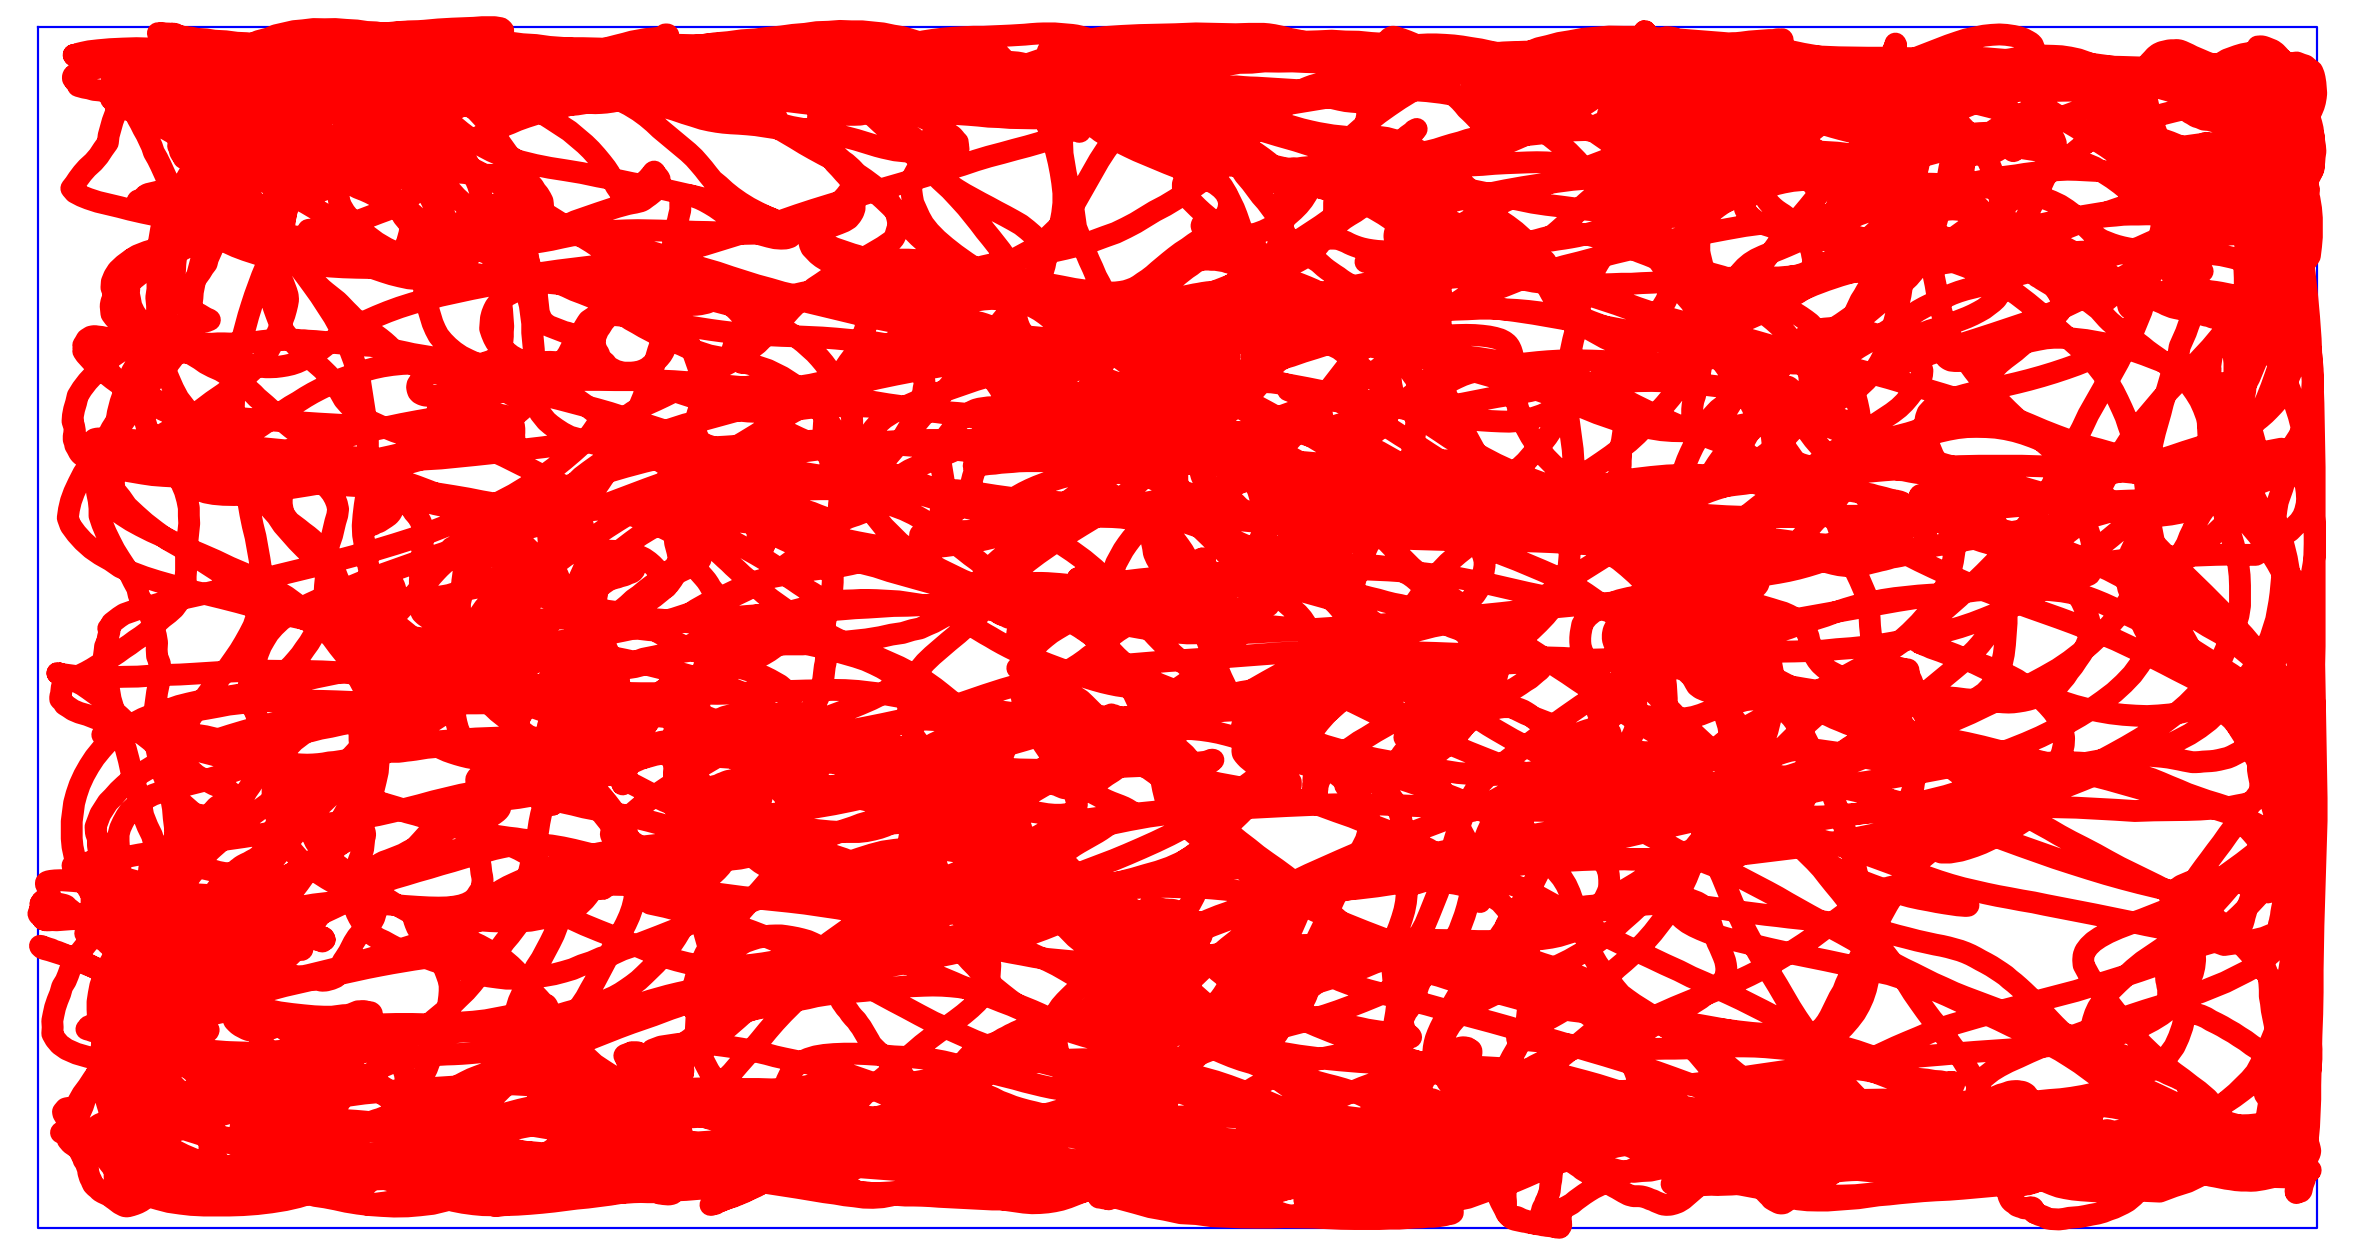

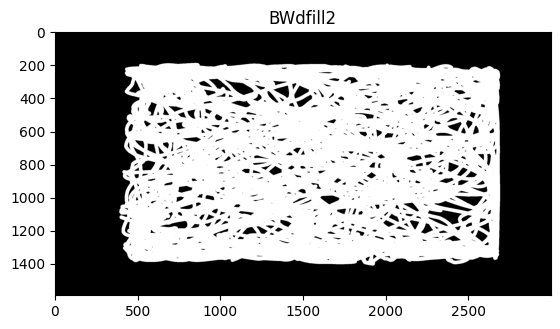

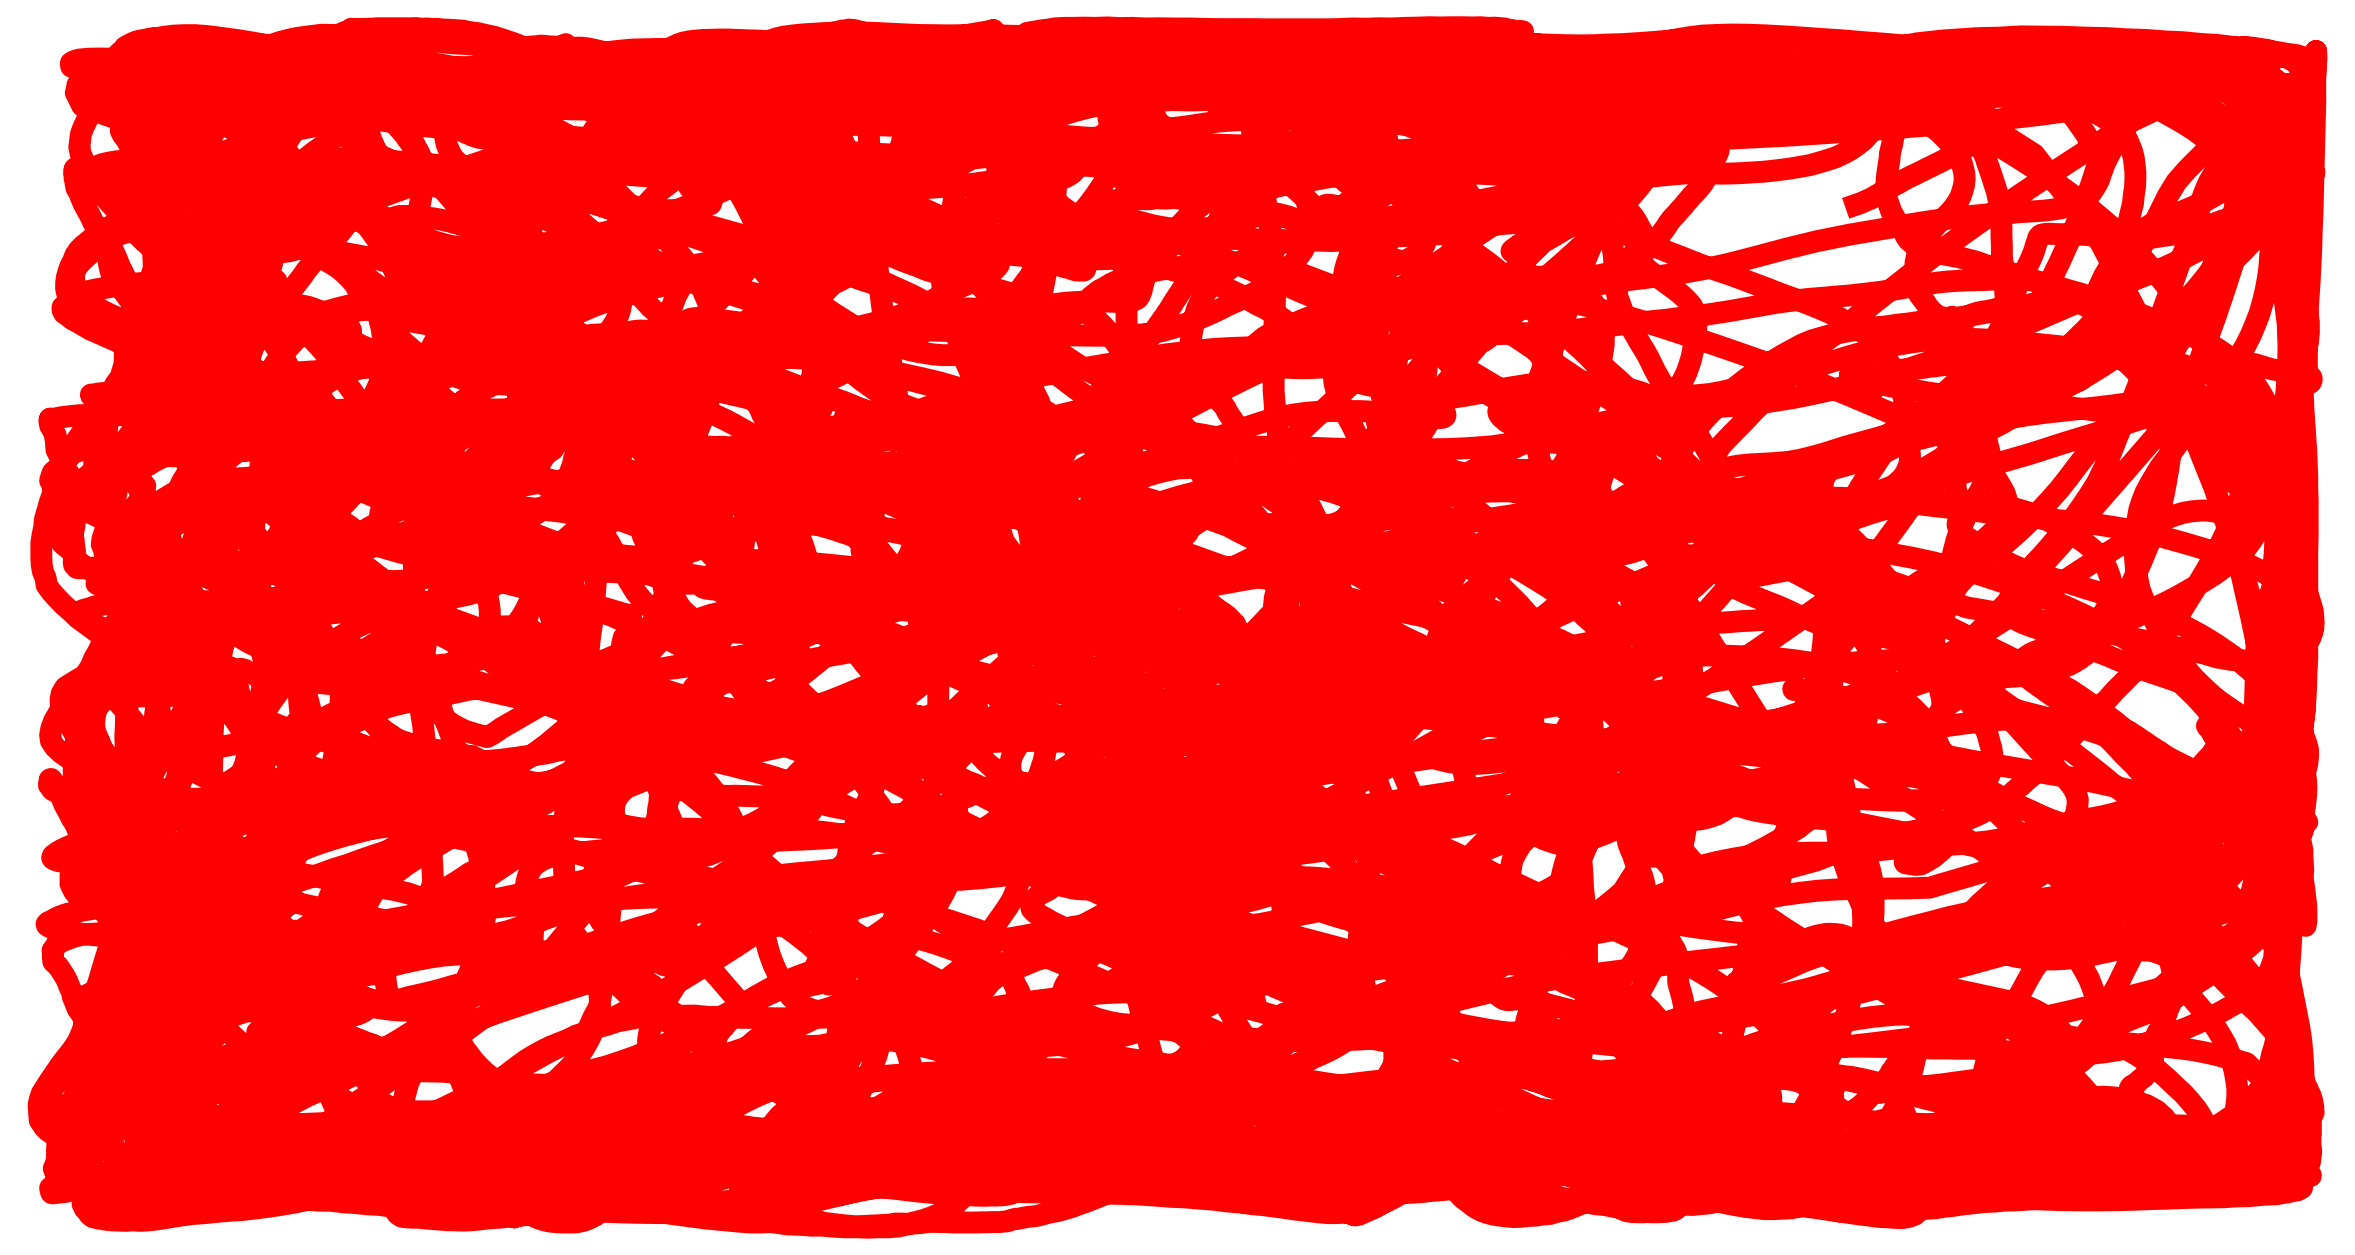

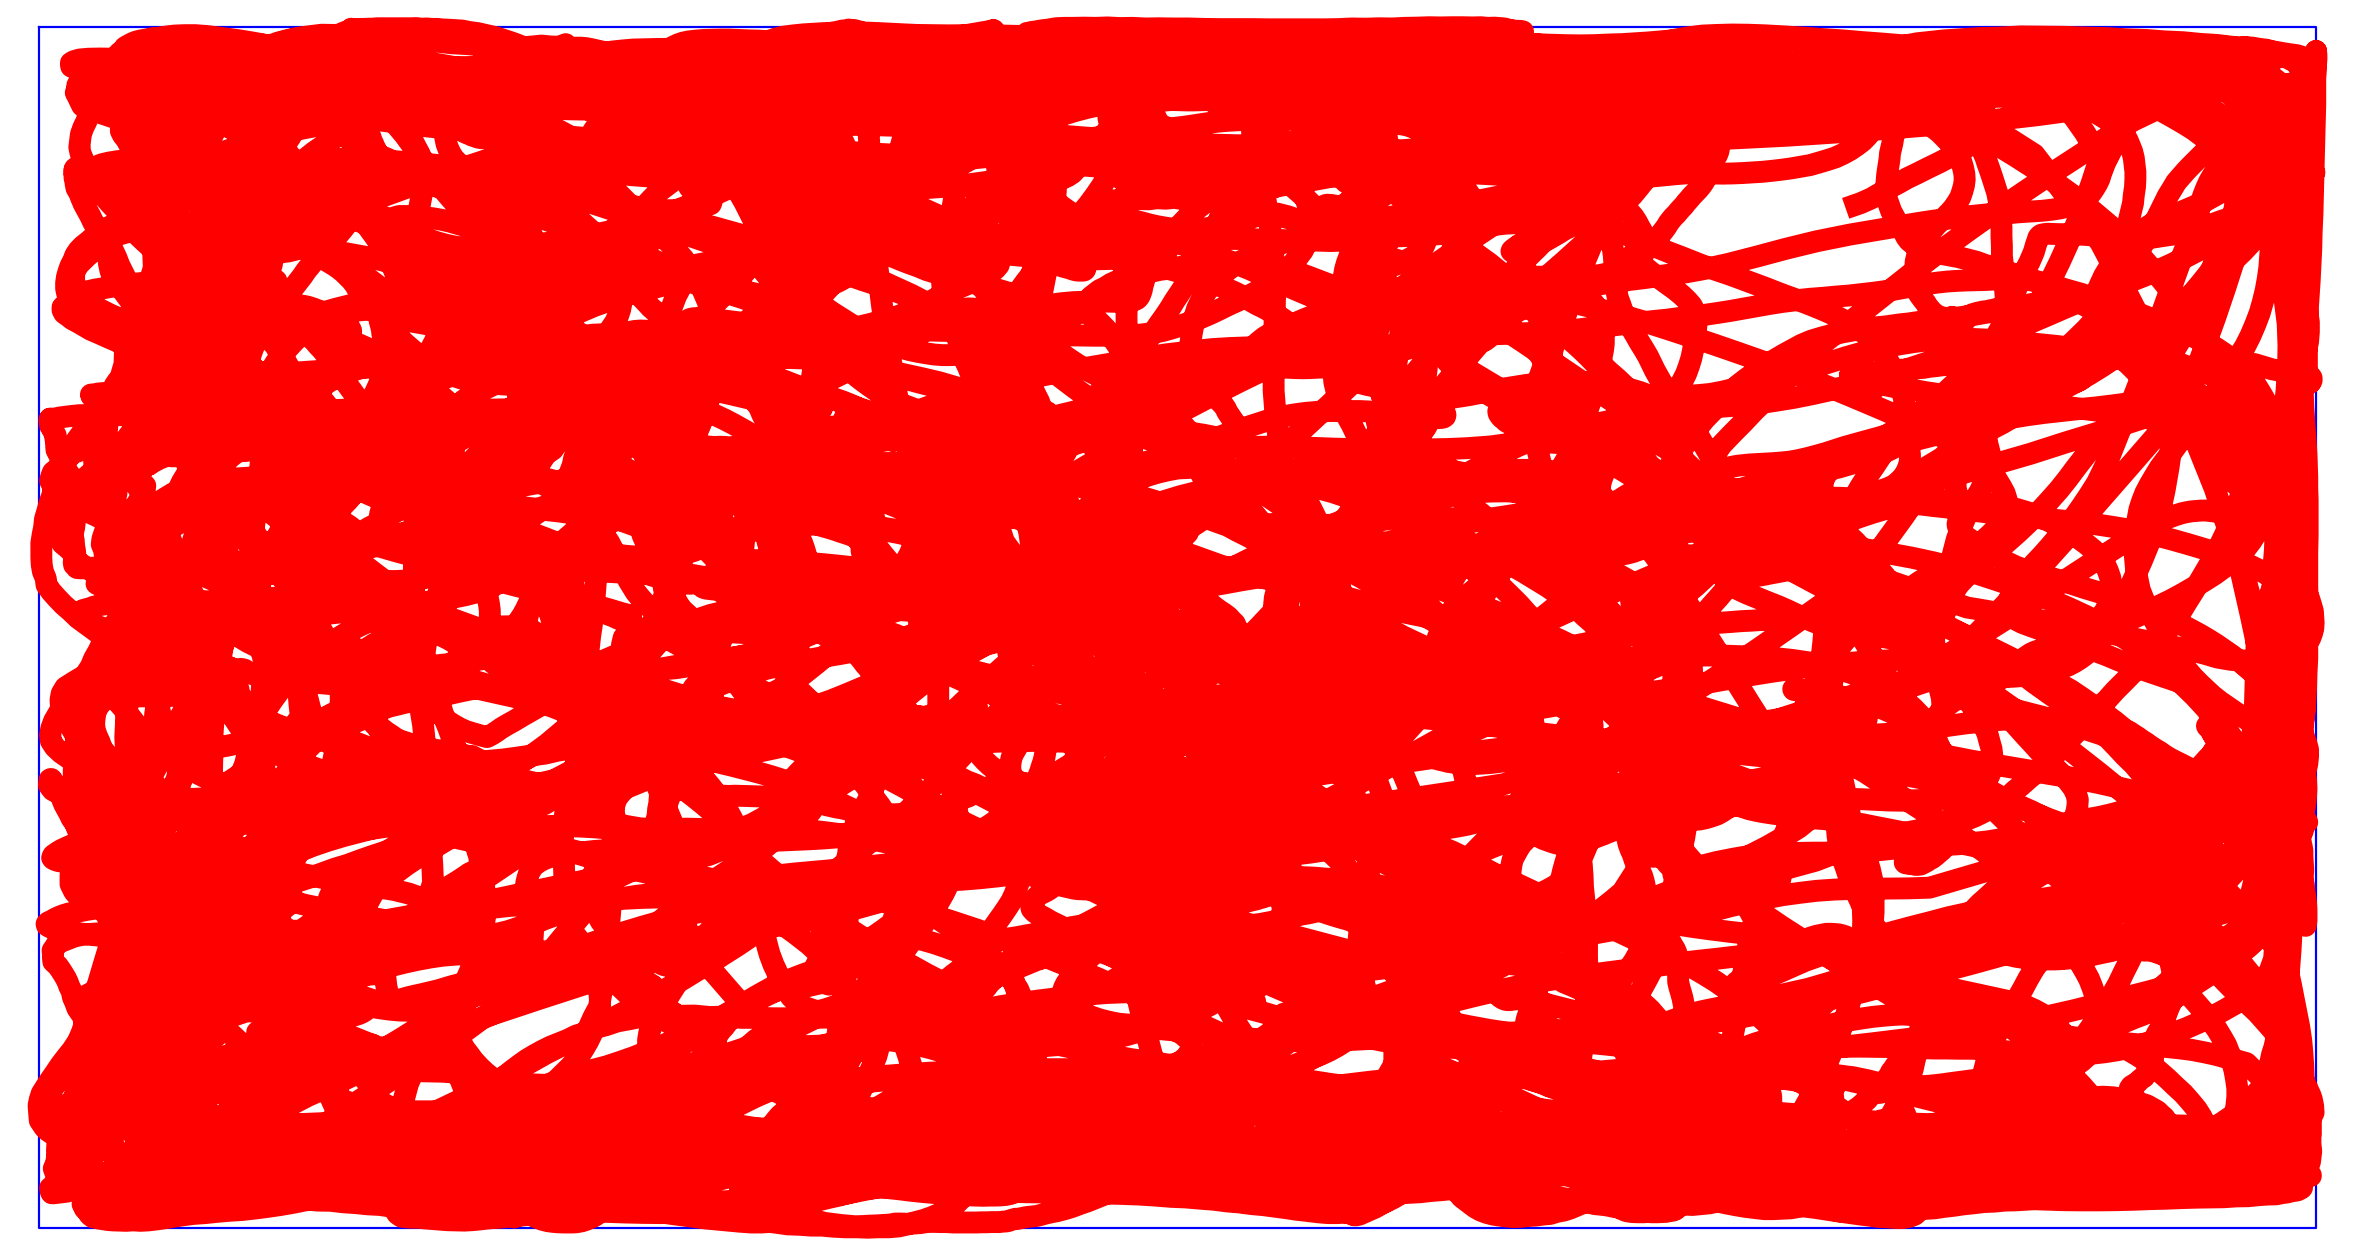

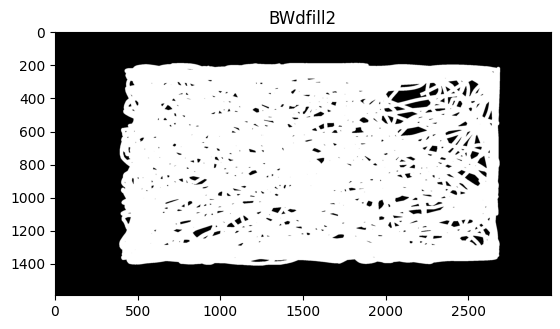

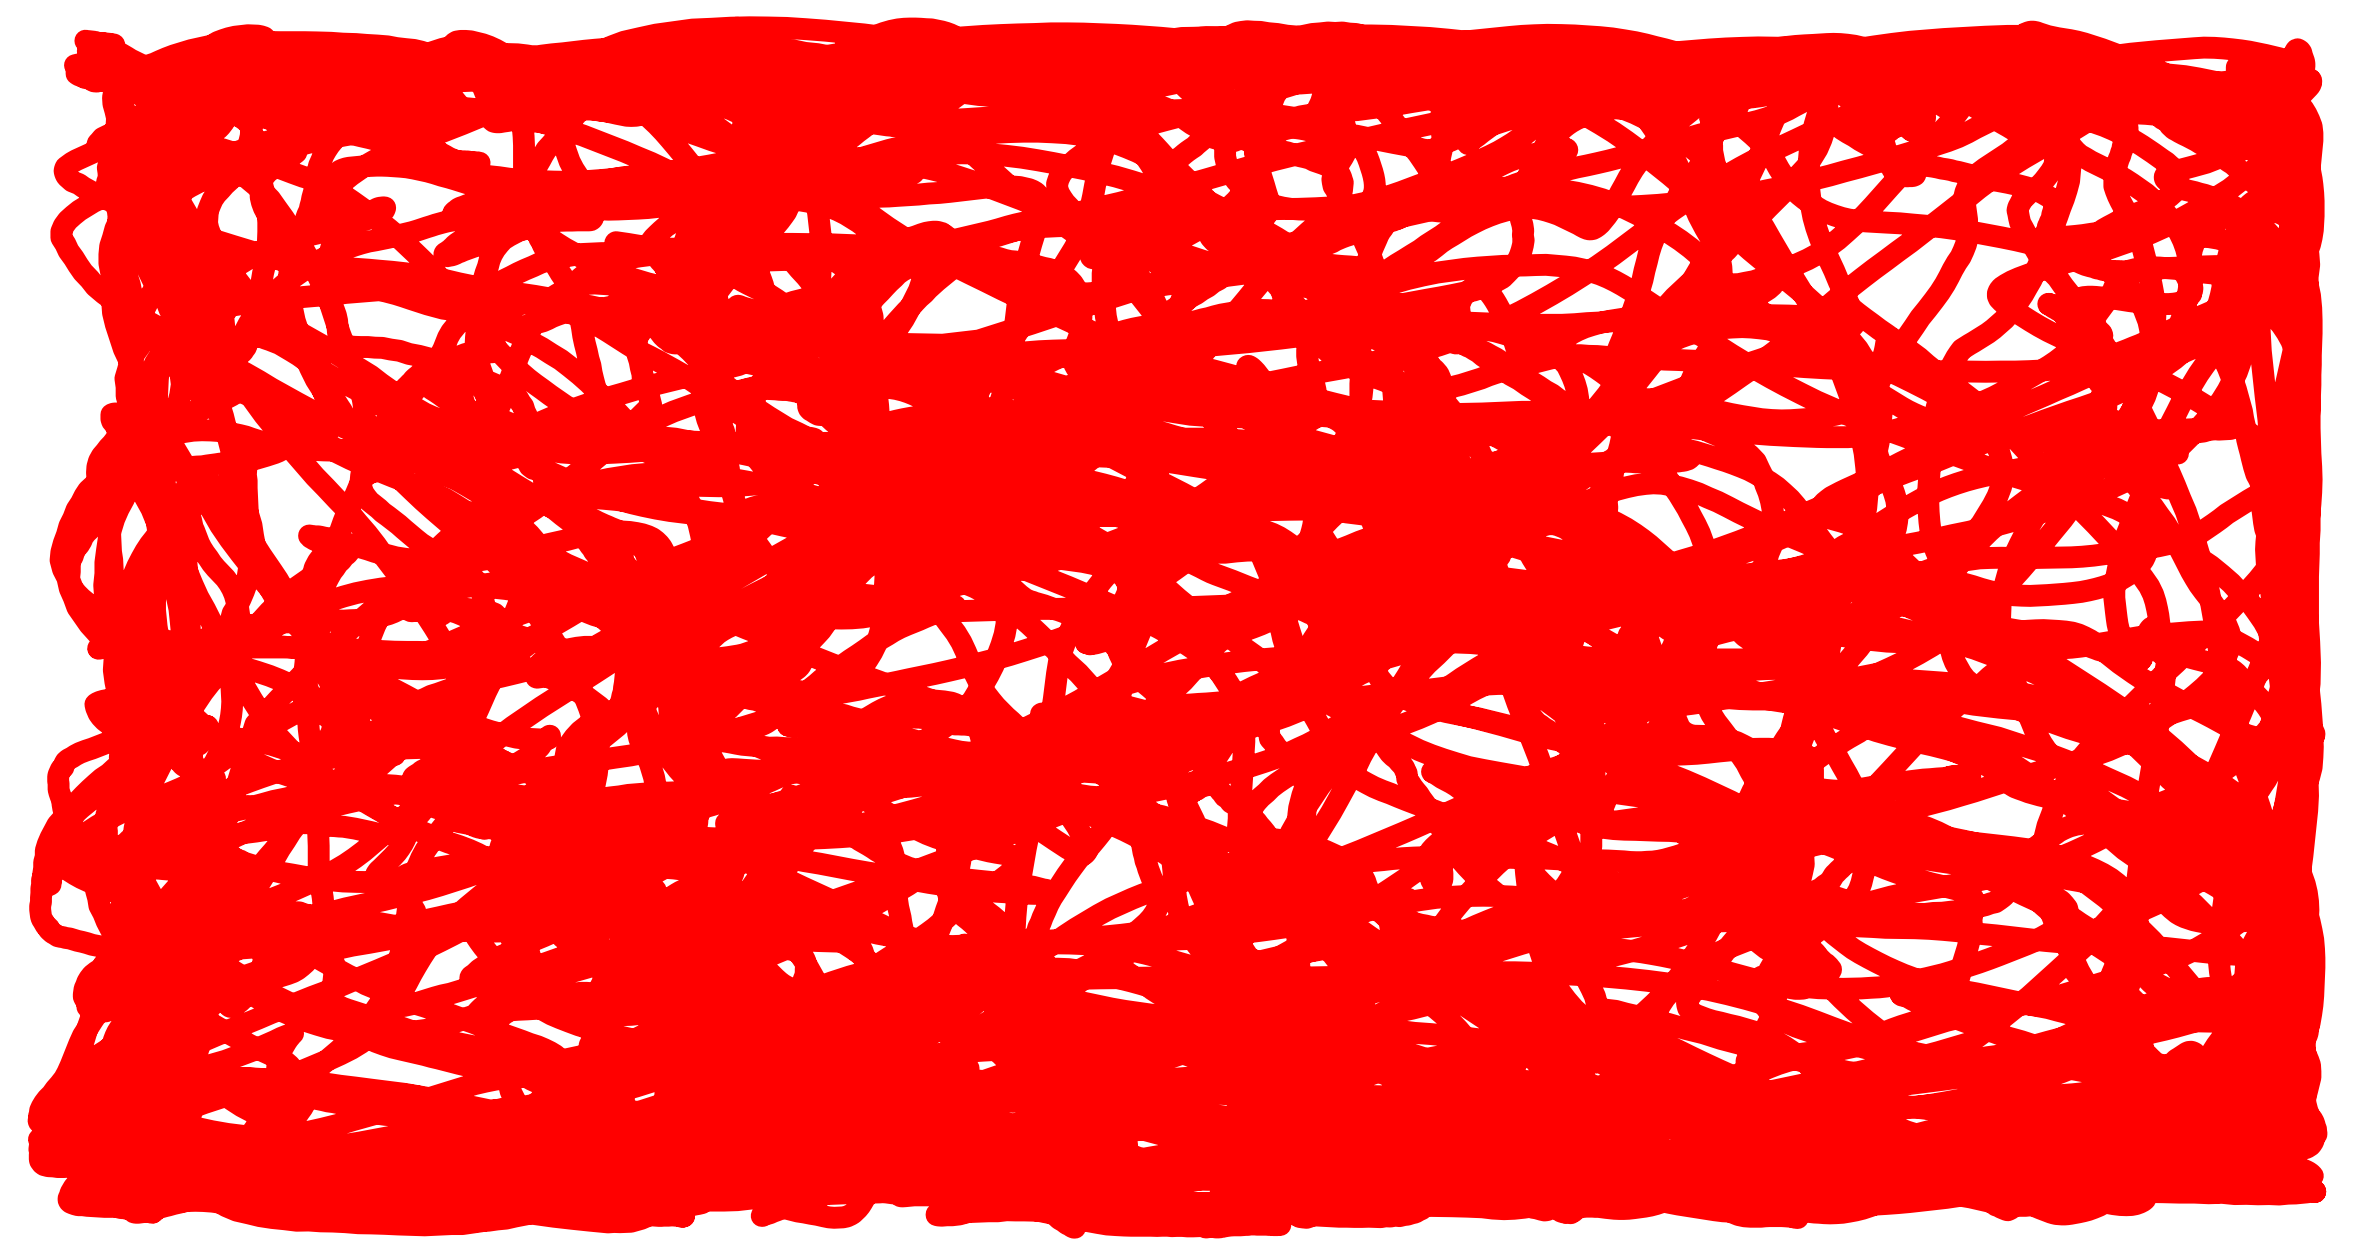

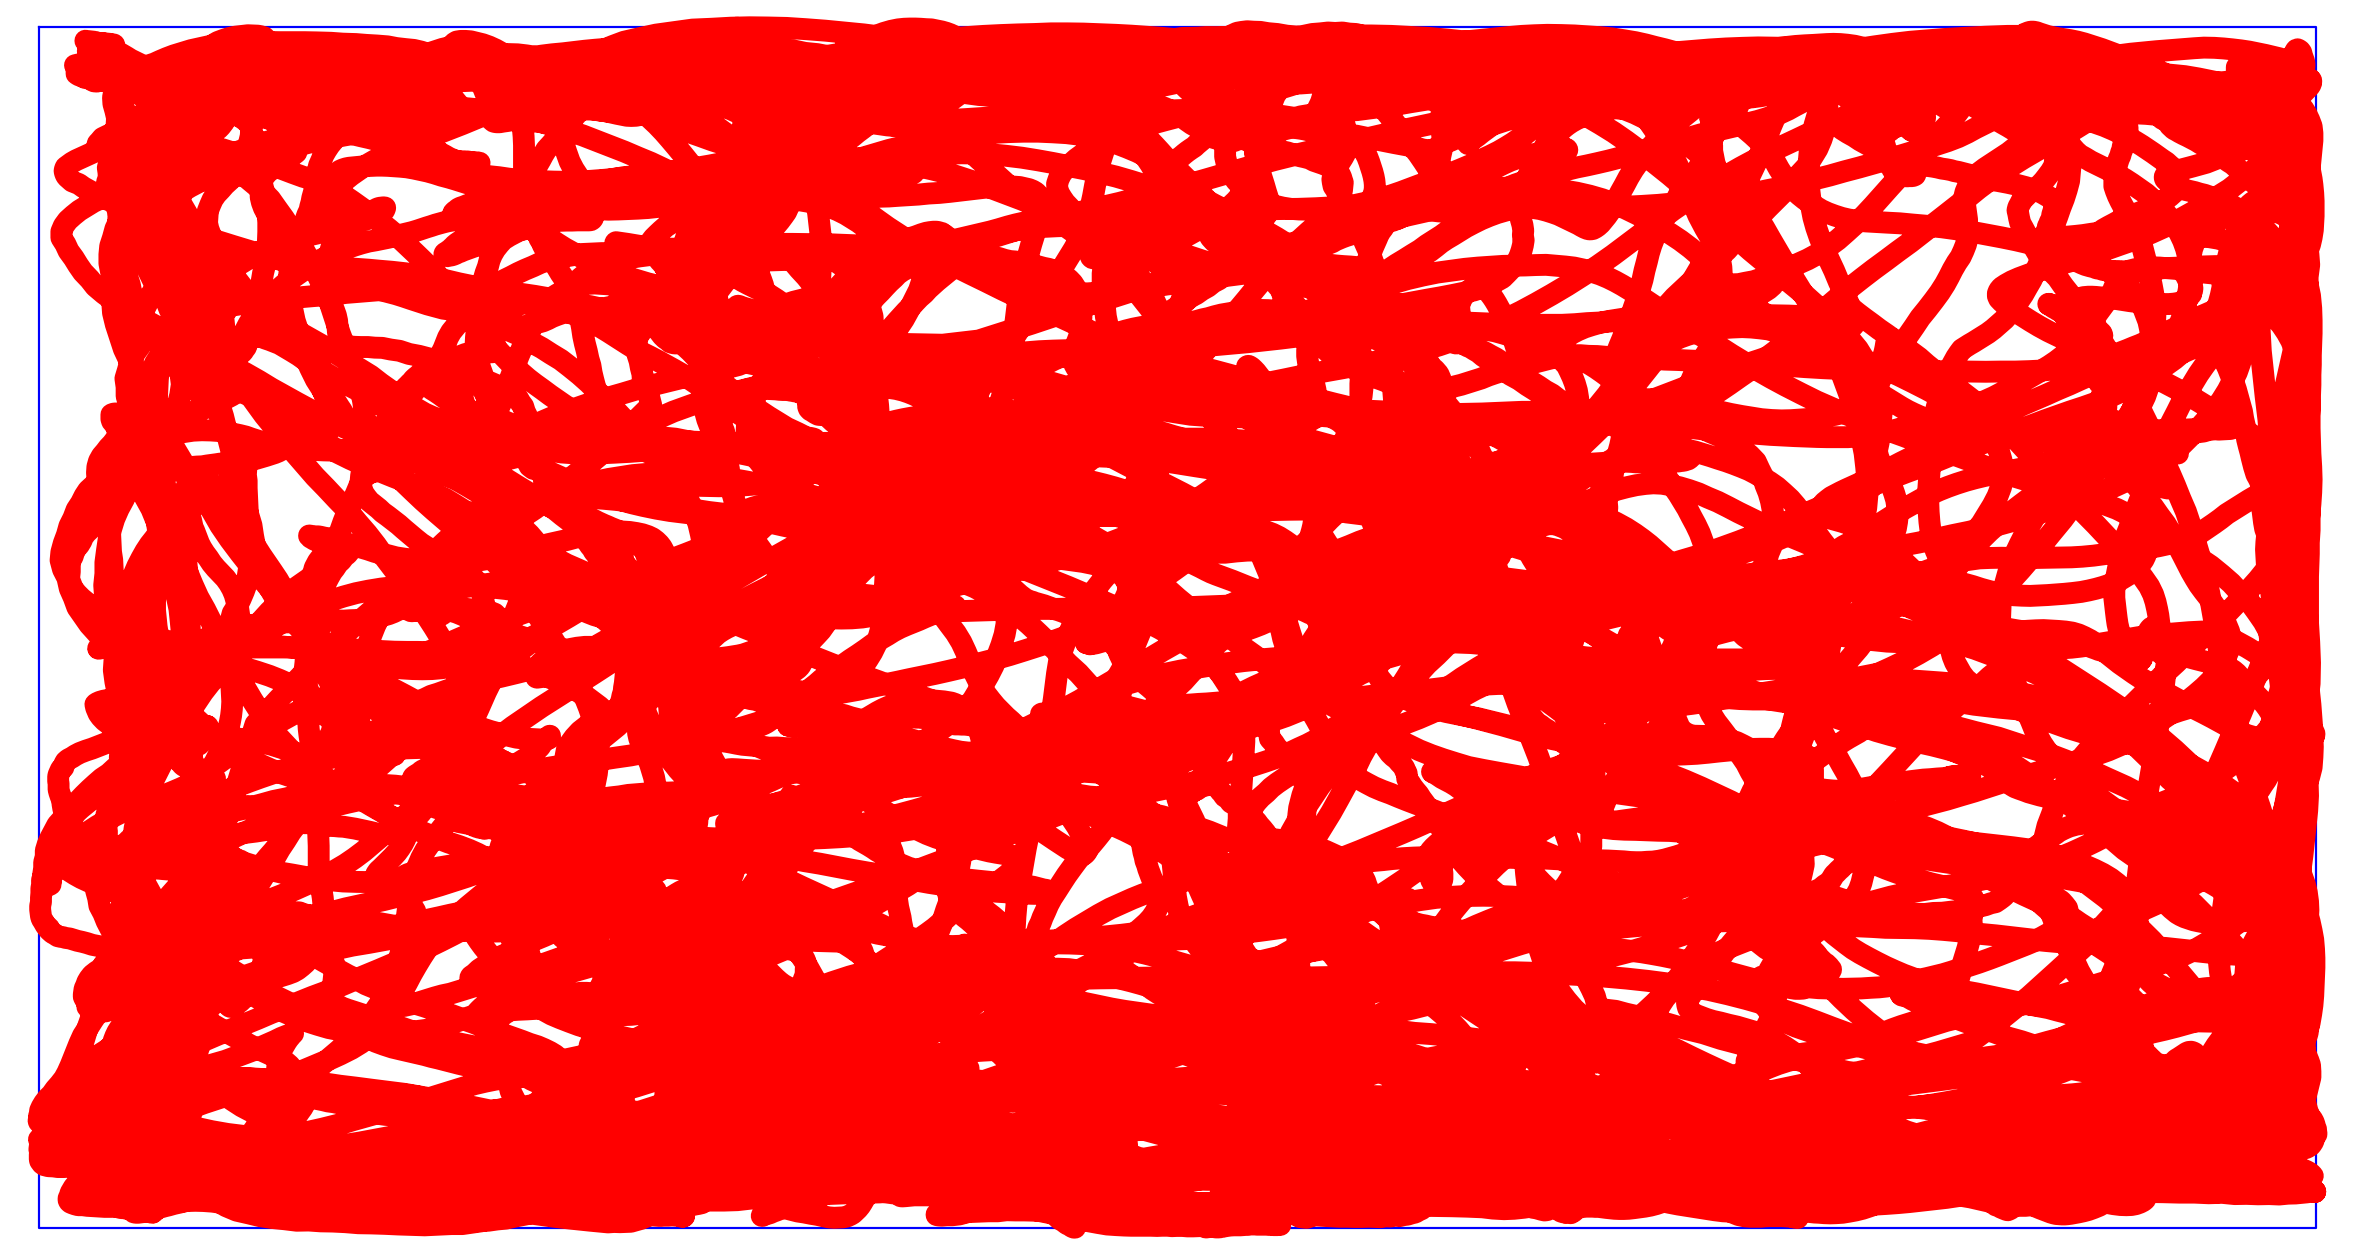

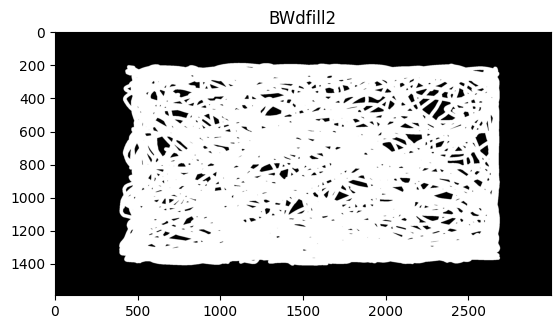

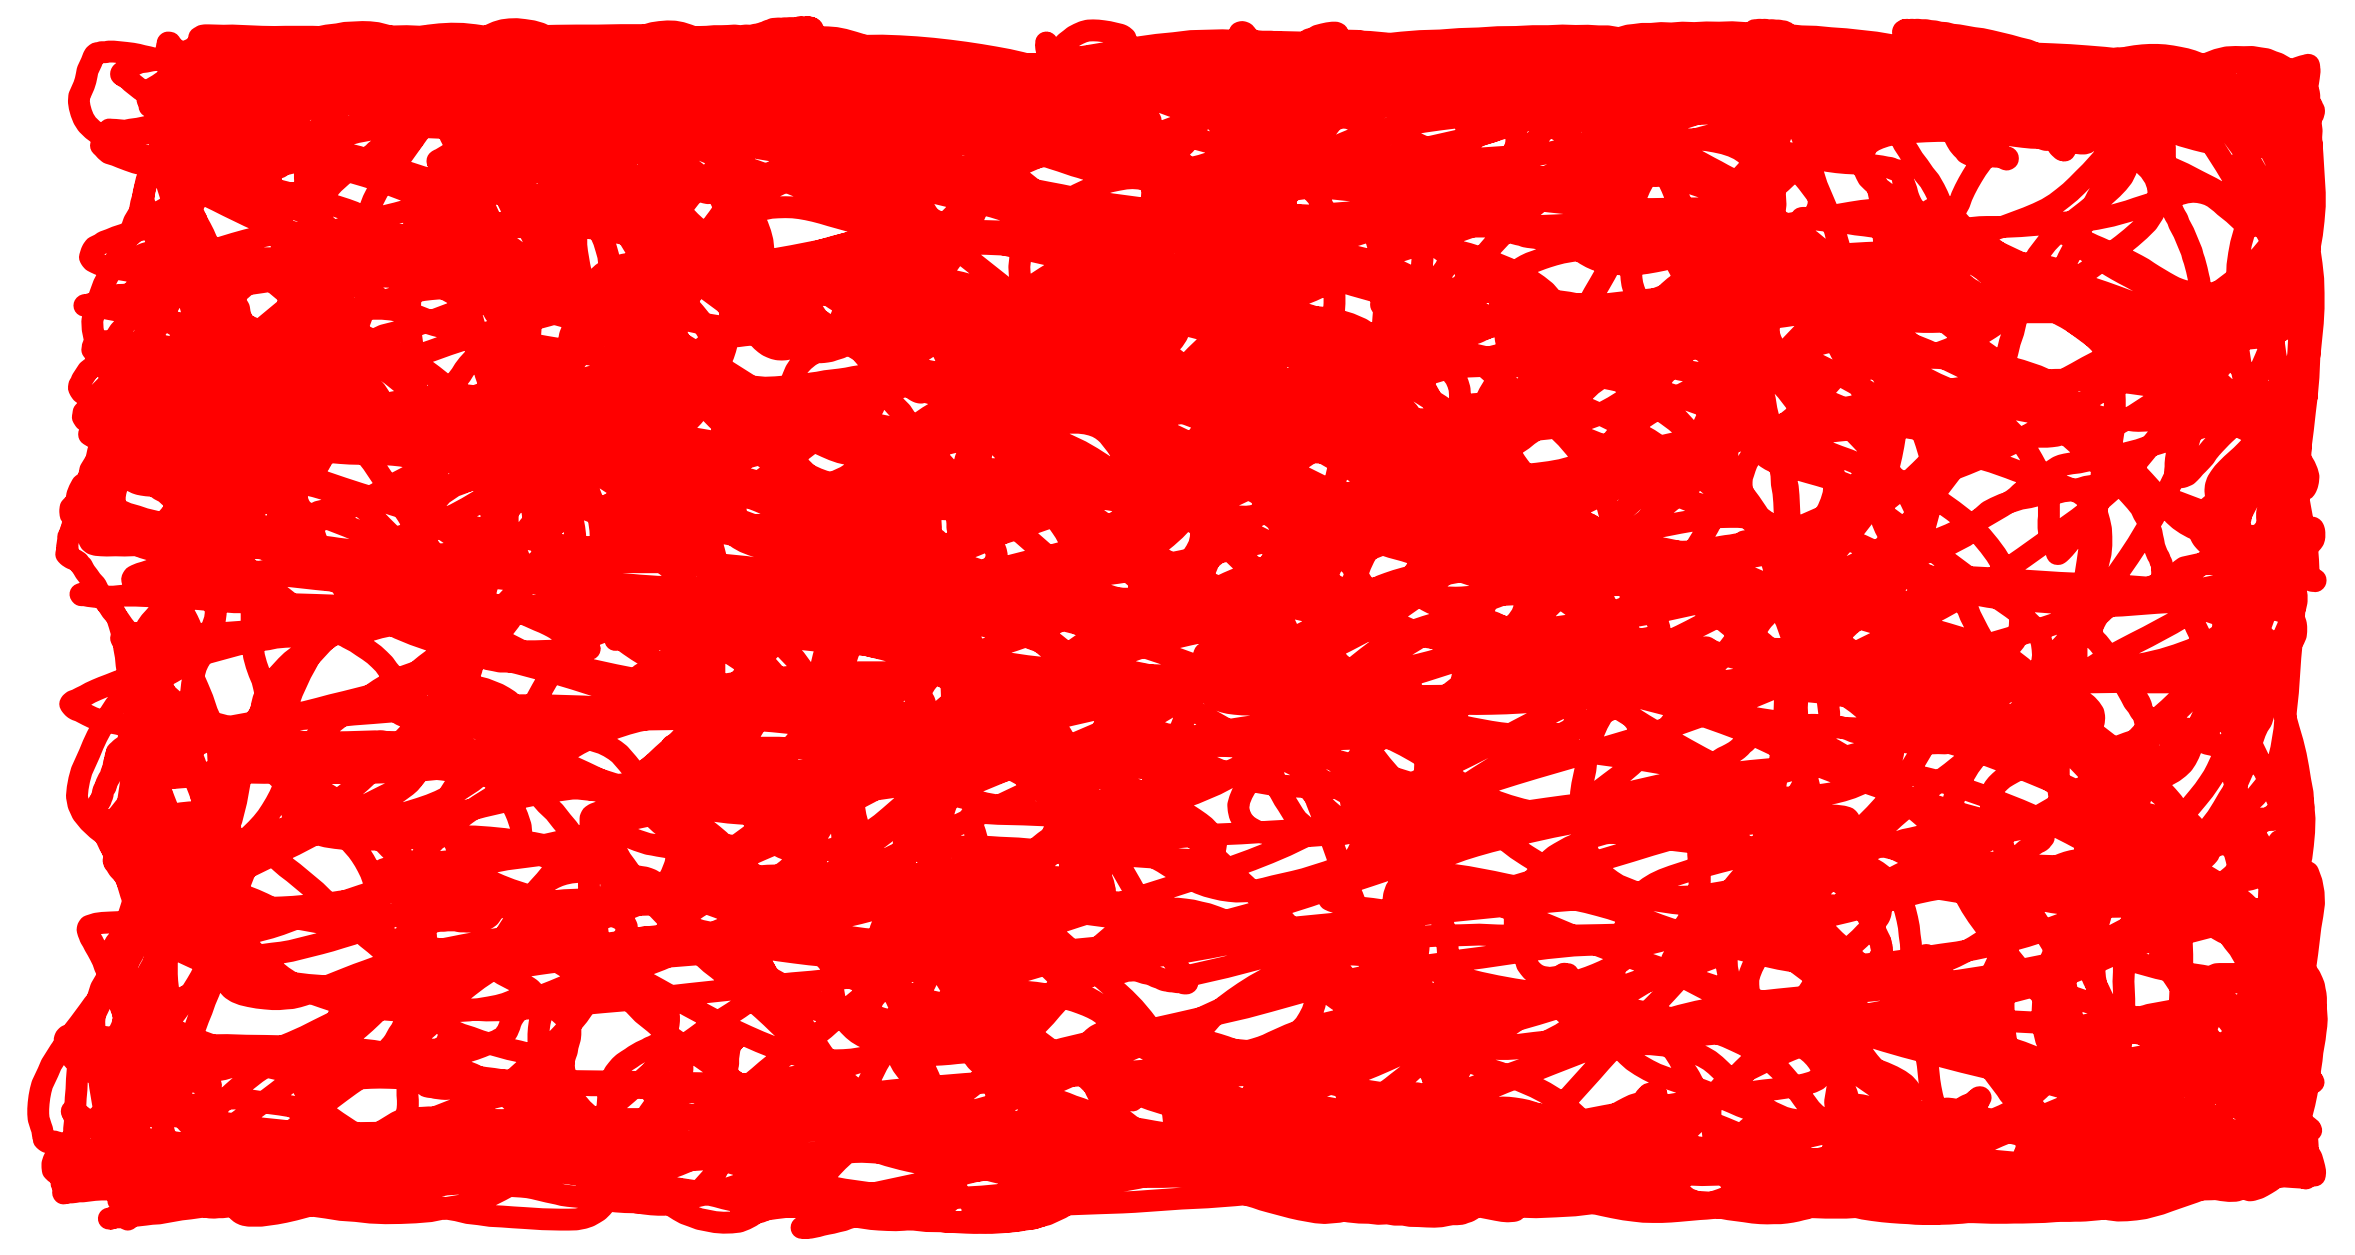

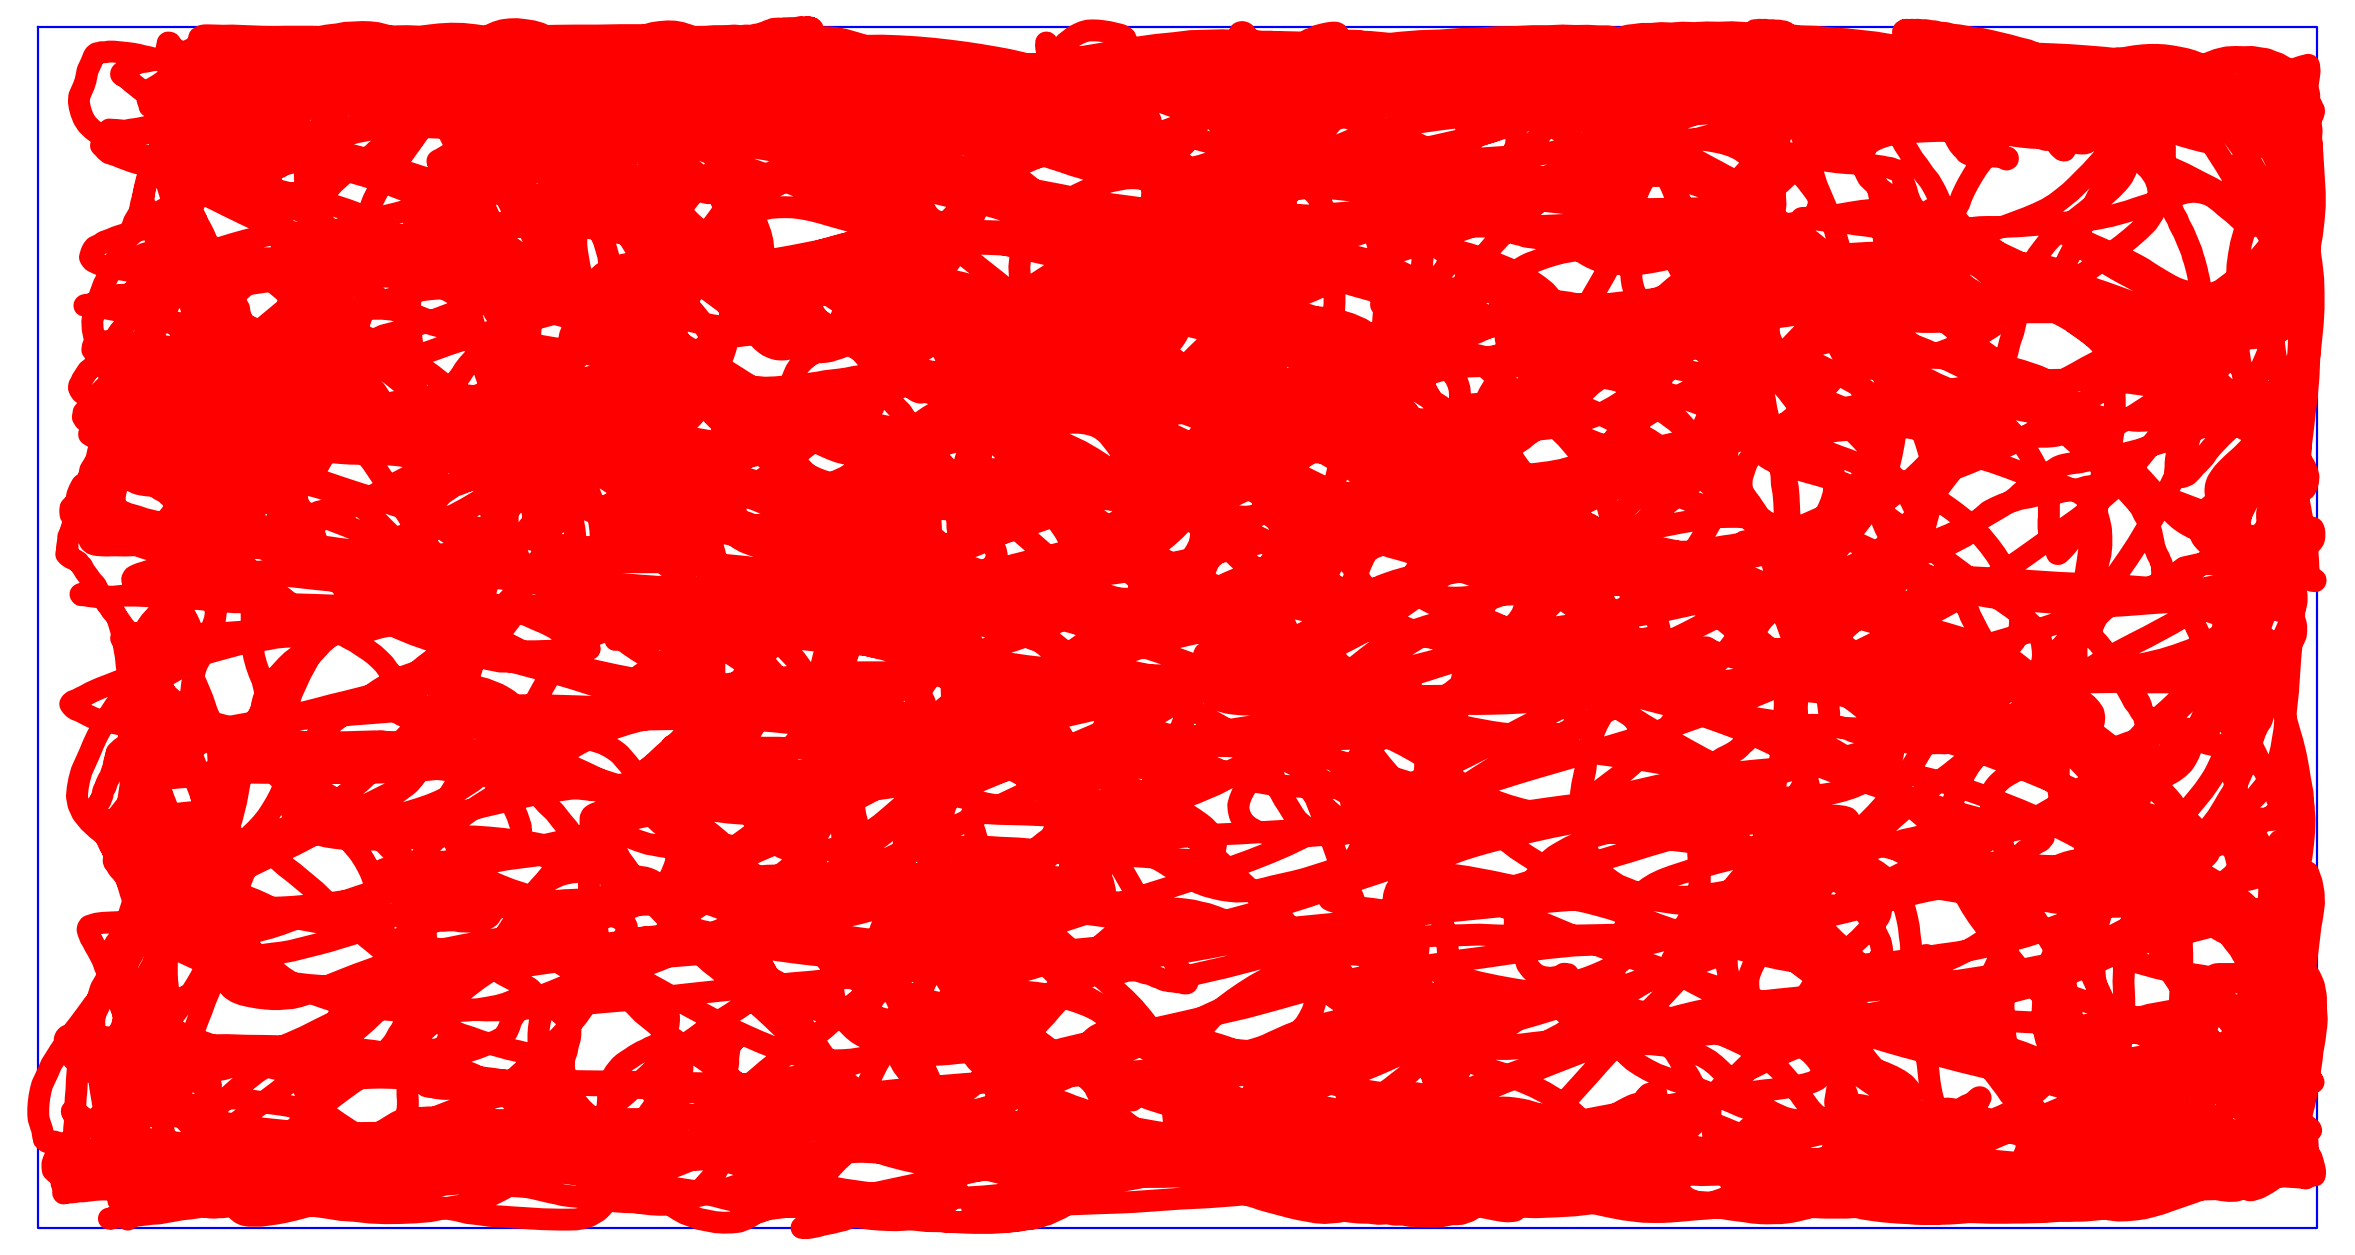

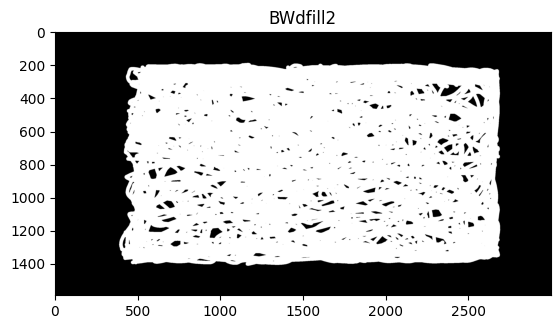

In [139]:
import time

save_dir = pathlib.Path.cwd().parent / r"data" / r"output"

animal = {'animal_id': '1-13', 'species': 'mouse', 'sex': 'F', 'age': 1, 'weight': 1, 'genotype': 'type', 'animal_notes': 'notes'}
devices = {'axona_led_tracker': True, 'implant': True}
implant = {'implant_id': '001', 'implant_type': 'tetrode', 'implant_geometry': 'square', 'wire_length': 25, 'wire_length_units': 'um', 'implant_units': 'uV'}

csv_header = {}
plotTasks = {}
csv_header_keys = ['signature', 'total_area', 'total_filled', 'coverage', 'min_speed',
                    'max_speed', 'mean_speed', 'median_speed', 'total_distance', "centre_distance",
                    "centre_coverage", "boundaries_distance", "boundaries_coverage"]

num_bins = 4
for i in range(1, num_bins+1):
    for j in range(1, num_bins+1):
        csv_header_keys.append(f"bin_distance_r{i}_c{j}")
for i in range(1, num_bins+1):
    for j in range(1, num_bins+1):
        csv_header_keys.append(f"bin_coverage_r{i}_c{j}")
                    
for key in csv_header_keys:
    csv_header[key] = True

session_settings = {'channel_count': 4, 'animal': animal, 'devices': devices, 'implant': implant}
settings = {'ppm': None, 'session':  session_settings, 'smoothing_factor': 2, 'useMatchedCut': False}

tasks = {}
tasks['disk_arena'] = False # -->
settings['tasks'] = tasks # --> change tasks array to change tasks are run
settings['plotTasks'] = plotTasks # --> change plot tasks array to change asks taht are plotted
settings['header'] = csv_header # --> change csv_header header to change tasks that are saved to csv

""" FOR YOU TO EDIT """
settings['arena_size'] = (50,50)
settings['speed_lowerbound'] = 3
settings['speed_upperbound'] = 100
settings['end_cell'] = None
settings['start_cell'] = None

start_time = time.time()
# root = tk.Tk()
# root.withdraw()
# data_dir = filedialog.askdirectory(parent=root,title='Please select a data directory.')

########################################################################################################################
with unit_of_work as uow:
    query = {
        "schema_ref": "animal_position"
    }
    sorted_by = [("session_start", -1)]
    sessions = uow.data.find(query)
    batch_map_via_queries(uow, sessions, settings, save_dir)


In [24]:
with unit_of_work as uow:
    query = {
        "schema_ref": "animal_position"
    }
    sorted_by = [("session_start", -1)]
    sessions = uow.data.find(query)

    for i in range(len(sessions)):
        print(sessions[i])

{'sample_rate': '50.0', 'session_data_ref': {'schema_ref': 'session', 'data_name': '1-13_20210510_163938'}, 'animal_data_ref': {'schema_ref': 'animal', 'data_name': '1-13'}, 'has_file': True, 'schema_ref': 'animal_position', 'data_name': '1-13_20210510_163938', 'recording_length': '20210510', 'data_dimensions': ['sample', 'xyt'], 'dimension_of_measure': '[space]', 'unit_of_measure': 'cm', 'time_of_save': datetime.datetime(2025, 3, 21, 23, 20, 34, 549429), 'time_of_removal': None}
{'sample_rate': '50.0', 'session_data_ref': {'schema_ref': 'session', 'data_name': '1-13_20210511_104628'}, 'animal_data_ref': {'schema_ref': 'animal', 'data_name': '1-13'}, 'has_file': True, 'schema_ref': 'animal_position', 'data_name': '1-13_20210511_104628', 'recording_length': '20210511', 'data_dimensions': ['sample', 'xyt'], 'dimension_of_measure': '[space]', 'unit_of_measure': 'cm', 'time_of_save': datetime.datetime(2025, 3, 21, 23, 20, 35, 88755), 'time_of_removal': None}
{'sample_rate': '50.0', 'sessio

In [46]:
import numpy as np

def centreBox(posx, posy):
    """
    Computes the centre of the box defined by posx and posy.

    Parameters:
      posx: array-like, x-coordinates of the points.
      posy: array-like, y-coordinates of the points.

    Returns:
      list: [x, y] coordinates of the centre.
    """
    maxX = np.max(posx)
    minX = np.min(posx)
    maxY = np.max(posy)
    minY = np.min(posy)
    
    # Define the corners of the box
    NE = [maxX, maxY]
    NW = [minX, maxY]
    SW = [minX, minY]
    SE = [maxX, minY]
    
    centre = findCentre(NE, NW, SW, SE)
    return centre

def findCentre(NE, NW, SW, SE):
    """
    Calculates the centre of the box from the corner coordinates.
    The centre is the intersection of the diagonals.

    Parameters:
      NE, NW, SW, SE: list or array containing the [x, y] coordinates of the corners.
      
    Returns:
      list: [x, y] coordinates of the centre.
    """
    # Compute slopes for the diagonals
    a = (NE[1] - SW[1]) / (NE[0] - SW[0])  # slope for NE-SW diagonal
    b = (SE[1] - NW[1]) / (SE[0] - NW[0])  # slope for SE-NW diagonal
    c = SW[1]
    d = NW[1]
    x = (d - c + a * SW[0] - b * NW[0]) / (a - b)
    y = a * (x - SW[0]) + c
    return [x, y]

# Test script in Python
if __name__ == '__main__':
    # Create example data corresponding to a square
    posx = np.array([0, 10, 10, 0])
    posy = np.array([0, 0, 10, 10])
    
    centre = centreBox(posx, posy)
    print("Computed centre in Python: (%.2f, %.2f)" % (centre[0], centre[1]))



Computed centre in Python: (5.00, 5.00)


In [2]:
from PIL import Image

# Open the image file
img = Image.open("/Users/Anurag/Downloads/NeuroLab/Data/matlab_figures/Figures/1-13_20210510-17-50x50cm-1200um-Test1_coverage.png")

# Get image dimensions in pixels (width, height)
width_px, height_px = img.size
print("Image size (pixels):", (width_px, height_px))

# Try to get DPI information from the image metadata.
# Note: Not all PNG images include DPI metadata.
dpi = img.info.get("dpi", (72, 72))  # default to 72 dpi if not available
print("DPI:", dpi)

# Calculate figure size in inches
fig_width_in = width_px / dpi[0]
fig_height_in = height_px / dpi[1]
print("Figure size (inches):", (fig_width_in, fig_height_in))


Image size (pixels): (3000, 1591)
DPI: (150.01239999999999, 150.01239999999999)
Figure size (inches): (19.998346803330925, 10.605789921366501)


In [9]:
from PIL import Image

# Open the image file
img = Image.open("/Users/Anurag/Downloads/NeuroLab/Data/matlab_figures/Figures/1-13_20210511-18-50x50cm-1200um-Test4_filled.png")

# Get image dimensions in pixels (width, height)
width_px, height_px = img.size
print("Image size (pixels):", (width_px, height_px))

# Try to get DPI information from the image metadata.
# Note: Not all PNG images include DPI metadata.
dpi = img.info.get("dpi", (72, 72))  # default to 72 dpi if not available
print("DPI:", dpi)

# Calculate figure size in inches
fig_width_in = width_px / dpi[0]
fig_height_in = height_px / dpi[1]
print("Figure size (inches):", (fig_width_in, fig_height_in))


Image size (pixels): (2616, 1389)
DPI: (150.01239999999999, 150.01239999999999)
Figure size (inches): (17.43855841250457, 9.259234569942219)


In [4]:
from PIL import Image

# Open the image file
img = Image.open("/Users/Anurag/Downloads/NeuroLab/Data/matlab_figures/Figures/1-13_20210510-17-50x50cm-1200um-Test1_total.png")

# Get image dimensions in pixels (width, height)
width_px, height_px = img.size
print("Image size (pixels):", (width_px, height_px))

# Try to get DPI information from the image metadata.
# Note: Not all PNG images include DPI metadata.
dpi = img.info.get("dpi", (72, 72))  # default to 72 dpi if not available
print("DPI:", dpi)

# Calculate figure size in inches
fig_width_in = width_px / dpi[0]
fig_height_in = height_px / dpi[1]
print("Figure size (inches):", (fig_width_in, fig_height_in))


Image size (pixels): (3000, 1591)
DPI: (150.01239999999999, 150.01239999999999)
Figure size (inches): (19.998346803330925, 10.605789921366501)


/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/40020823.py:11: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  RGB_matlab = imageio.imread(cover_png_total_matlab)
/var/folders/73/w5zh6s310tl6_n532vlv6tmw0000gp/T/ipykernel_59861/40020823.py:14: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  RGB_python = imageio.imread(cover_png_total_python)


Matlab image shape: (1591, 3000)
Python image shape: (1591, 3000)
The images are different.


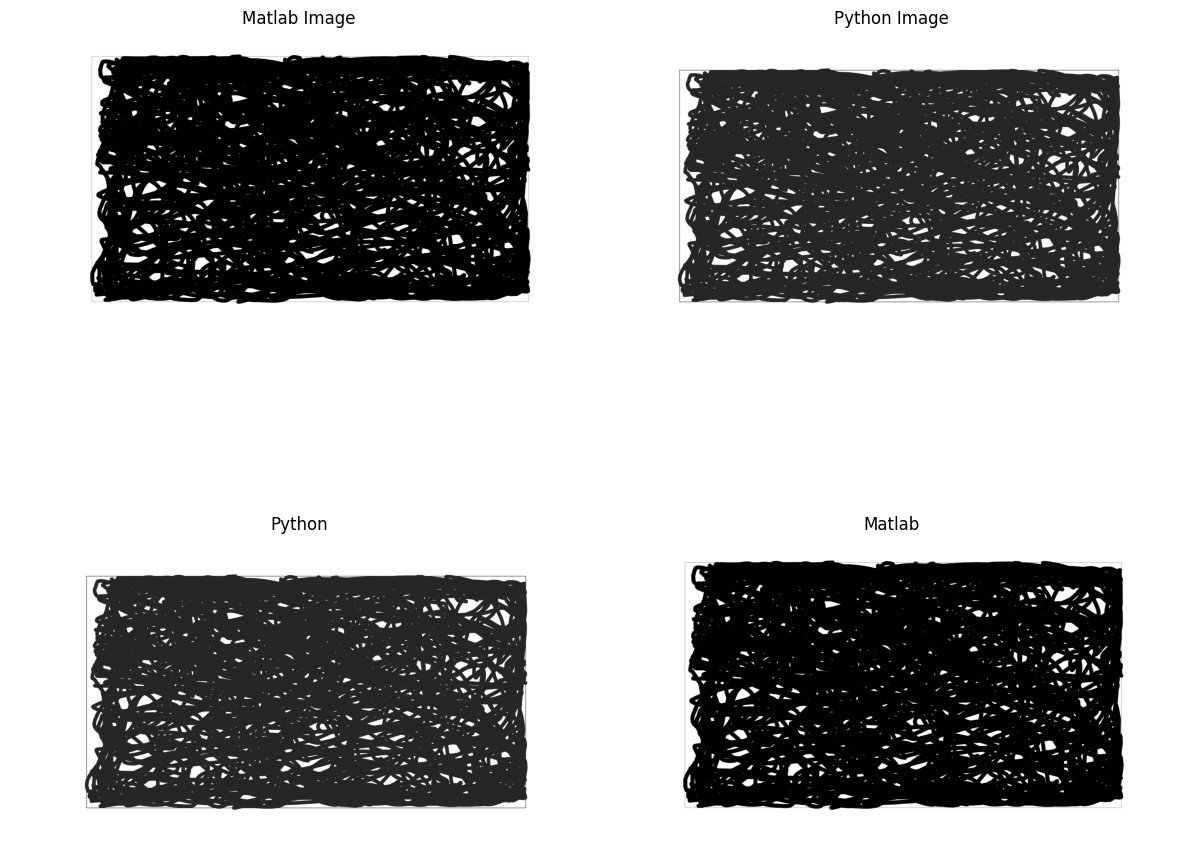

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import imageio
from skimage.color import rgb2gray

# File paths for the images
cover_png_total_matlab = "/Users/Anurag/Downloads/NeuroLab/Data/matlab_figures/Figures/1-13_20210510-17-50x50cm-1200um-Test1_total.png"
cover_png_total_python = "/Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/1-13_20210510_110723_total.png"

# Read images using imageio and convert to grayscale using rgb2gray
RGB_matlab = imageio.imread(cover_png_total_matlab)
I_matlab = rgb2gray(RGB_matlab)

RGB_python = imageio.imread(cover_png_total_python)
RGB_python = color.rgba2rgb(RGB_python)
I_python = rgb2gray(RGB_python)

# Print the shapes of the images
print("Matlab image shape:", I_matlab.shape)
print("Python image shape:", I_python.shape)

# Compare the images using np.allclose
if np.allclose(I_matlab, I_python, rtol=1e-05, atol=1e-08):
    print("The images are approximately equal.")
else:
    print("The images are different.")


# Plot both grayscale images side by side
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))

# Plot Matlab image
ax1.imshow(I_matlab, cmap='gray')
ax1.set_title("Matlab Image")
ax1.axis('off')  # Remove axis ticks and labels

# Plot Python image
ax2.imshow(I_python, cmap='gray')
ax2.set_title("Python Image")
ax2.axis('off')

# Plot combined image: Matlab then Python
ax3.imshow(I_python, cmap='gray')
ax3.set_title("Python")
ax3.axis('off')

# Plot combined image: Python then Matlab
ax4.imshow(I_matlab, cmap='gray')
ax4.set_title("Matlab")
ax4.axis('off')

plt.tight_layout()
plt.show()


In [58]:
from PIL import Image

def get_image_info(filename):
    """
    Reads an image and returns its resolution and DPI.
    
    Parameters:
      filename (str): Path to the image file.
    
    Returns:
      width (int): Image width in pixels.
      height (int): Image height in pixels.
      dpi (tuple): DPI values (dpi_x, dpi_y) if available, otherwise (None, None).
    """
    with Image.open(filename) as img:
        width, height = img.size
        # The DPI info is typically stored under the 'dpi' key in the image info dict.
        dpi = img.info.get('dpi', (None, None))
    return width, height, dpi

if __name__ == '__main__':
    # Replace with your image file path
    filename = "/Users/Anurag/Downloads/NeuroLab/Data/matlab_figures/Figures/1-13_20210510-17-50x50cm-1200um-Test1_total.png"
    width, height, dpi = get_image_info(filename)
    print("Image Resolution: {} x {} pixels".format(width, height))
    if dpi[0] is not None:
        print("DPI (X, Y): {}, {}".format(dpi[0], dpi[1]))
    else:
        print("DPI information not available.")


Image Resolution: 3000 x 1591 pixels
DPI (X, Y): 150.01239999999999, 150.01239999999999


In [134]:
df = pd.read_csv('/Users/Anurag/Downloads/NeuroLab/SignalStore/data/output/Animal_Performance_Results10/performance_summary.csv')
bin_distance_cols = [col for col in df.columns if col.startswith('bin_distance')]
bin_average_cols = [col for col in df.columns if col.startswith('bin_coverage')]

# Sum the bin distance values for each row
df['sum_bin_distance'] = df[bin_distance_cols].sum(axis=1)
df['equal_to_total_distance'] = np.isclose(df['sum_bin_distance'], df['total_distance'], rtol=1e-05, atol=1e-08)
df['coverage avg'] = df[bin_average_cols].mean(axis=1)
df 

,signature,total_area,total_filled,coverage,min_speed,max_speed,mean_speed,median_speed,total_distance,centre_distance,...,bin_coverage_r3_c2,bin_coverage_r3_c3,bin_coverage_r3_c4,bin_coverage_r4_c1,bin_coverage_r4_c2,bin_coverage_r4_c3,bin_coverage_r4_c4,sum_bin_distance,equal_to_total_distance,coverage avg
0,1-13_20210510_163938,2.771900e+06,2.421909e+06,87.373614,0.0,53.904924,7.726372,6.551506,91.521148,23.565299,...,90.645532,91.244160,78.046670,82.447695,85.436956,90.165951,79.960422,91.509264,False,85.804473
1,1-13_20210511_104628,2.771628e+06,2.559175e+06,92.334709,0.0,92.554046,9.992775,8.617971,118.774609,29.196199,...,94.711660,95.563625,89.869870,90.978306,93.741453,92.018173,84.524741,118.770619,False,91.331058
2,1-13_20210511_154137,2.770998e+06,2.491948e+06,89.929612,0.0,79.625909,8.930057,7.898045,104.709129,25.861250,...,92.190803,93.122102,90.258509,88.029380,95.102632,95.844843,88.686653,104.708365,True,88.732255
3,1-13_20210510_110723,2.769952e+06,2.550570e+06,92.079912,0.0,42.462857,9.902834,9.083589,115.918686,29.459789,...,96.174395,94.338293,91.878752,86.198778,91.767604,91.043072,89.549749,115.918686,True,89.946373


In [20]:
import yaml
with open("../app/src/animal_performance/queries_and_settings/settings.yml", "r") as f:
    settings = yaml.safe_load(f)

# Now `settings` is a Python dictionary
print(settings)

{'ppm': None, 'smoothing_factor': 3, 'useMatchedCut': False, 'arena_size': [50, 50], 'speed_lowerbound': 3, 'speed_upperbound': 100, 'end_cell': None, 'start_cell': None, 'num_bins': 16, 'saveData': True, 'saveMethod': 'one_for_parent', 'session': {'channel_count': 4, 'animal': {'species': 'mouse', 'genotype': 'type', 'animal_notes': 'notes'}, 'devices': {'axona_led_tracker': True, 'implant': True}, 'implant': {'implant_id': '001', 'implant_type': 'tetrode', 'implant_geometry': 'square', 'wire_length': 25, 'wire_length_units': 'um', 'implant_units': 'uV'}}, 'tasks': {'disk_arena': False, 'spike_width': True, 'spike_analysis': True, 'binary_map': True, 'autocorrelation_map': True, 'sparsity': True, 'selectivity': True, 'information': True, 'coherence': True, 'speed_score': True, 'hd_score': True, 'tuning_curve': True, 'grid_score': True, 'border_score': True, 'field_sizes': True}, 'plotTasks': {'binary_map': True, 'occupancy_map': True, 'Waveforms_Across_Channels': True, 'Spikes_Over_Po

## Neurofunc code 

In [27]:
PROJECT_PATH = '/Users/Anurag/Downloads/NeuroLab/NSK-isolated'
sys.path.append(PROJECT_PATH)
print(PROJECT_PATH)
from openpyxl.utils.cell import get_column_letter
from library.cluster.features import create_features
from library.hafting_spatial_maps import SpatialSpikeTrain2D
from library.map_utils import _speed2D
from library.cluster import create_features, L_ratio, isolation_distance
sys.path.append('/Users/Anurag/Downloads/NeuroLab/SignalStore/app/src')
from animal_performance.spiketrain import SpatialSpikeTrain2D_signalstore, WaveformTemplateFig
from animal_performance.waveform import troughs
from animal_performance.utils import extract_arena_size_from_shape,speed2D, insert_to_df_summary, flat_disk_mask
import warnings
from animal_performance.spikes import binary_map, rate_map_coherence, find_burst, histogram_ISI, firing_rate_vs_time
from animal_performance.score import autocorrelation, rate_map_stats, speed_score, hd_score, grid_score, border_score, spatial_tuning_curve, map_blobs, get_hd_score_for_cluster
from matplotlib import cm
from PIL import Image

/Users/Anurag/Downloads/NeuroLab/NSK-isolated


In [36]:
def batch_map_via_queries(data, cell, FD, settings_dict, session_position, df_summary, root_directory_paths, tetrode_directory_paths):

    columns = ['Session', 'Tetrode', 'Cell ID']
    tasks = settings_dict['tasks']
    plotTasks = settings_dict['plotTasks']
    csv_header = settings_dict['header']
    arena_size = settings_dict['arena_size']
    

    # Kernel size
    kernlen = int(settings_dict['smoothing_factor']*8)
    # Standard deviation size
    std = int(0.2*kernlen)

    # Set flag if no arguments were provided for later
    all_cells = False
    if (settings_dict['start_cell'] == settings_dict['end_cell'] == None):
        all_cells = True

    # Initialize empty dataframe with columns
    headers = [k for k, v in csv_header.items() if v]
    if 'border_score' in headers:
        idx = headers.index('border_score') 
        # print(idx)
        headers.remove('border_score')
        headers.insert(idx, 'border_score_top')
        headers.insert(idx+1, 'border_score_bottom')
        headers.insert(idx+2, 'border_score_left')
        headers.insert(idx+3, 'border_score_right')

    if len(df_summary) == 0:
        df_summary = pd.DataFrame(columns=columns+headers)

    session_query = data
    session_name = next(iter(session_query))
    waveform_array = session_query[session_name]['tet_waveforms']
    spike_times = session_query[session_name]['spike_times']
    # print('data name', session_name)
    signature = session_position.attrs["session_data_ref"]["data_name"]
    animal_id = waveform_array.attrs["animal_data_ref"]['data_name']
    tet_id = waveform_array.attrs["probe_data_ref"]['data_name']
    
    if settings_dict['saveMethod'] == 'one_for_parent':
        excel_cell_index = settings['per_animal_tracker']
    elif settings_dict['saveMethod'] == 'one_per_animal_tetrode':
        excel_cell_index = settings['per_animal_tetrode_tracker']
    elif settings_dict['saveMethod'] == 'one_per_session':
        excel_cell_index = settings['per_session_tracker']

    # Insert or overwrite the row at the target index
    df_summary.loc[excel_cell_index] = {
        'Session': signature,
        'Tetrode': tet_id,
        'Cell ID': cell
    }
    if all_cells == True or ((all_cells==False) & (cell >= settings_dict['start_cell'] & cell <= settings_dict['end_cell'])):
        print('animal: ' + str(animal_id) + ', session: ' + str(settings['per_session_tracker'] + 1) + ', cell_cluster_label: ' + str(cell))
        spatial_spike_train = SpatialSpikeTrain2D_signalstore({'cell': cell,
                                                               'position': session_position,
                                                               'spike_times': spike_times,
                                                               'speed_bounds': (settings_dict['speed_lowerbound'], settings_dict['speed_upperbound'])},
                                                               arena_size=arena_size,
                                                               smoothing_factor=settings_dict['smoothing_factor'],
                                                               isCylinder=settings_dict.get('isCylinder', False))
        pos_x, pos_y, pos_t, arena_size = spatial_spike_train.x, spatial_spike_train.y, spatial_spike_train.t, spatial_spike_train.arena_size
        v = speed2D(spatial_spike_train.x, spatial_spike_train.y, spatial_spike_train.t)
        rate_obj = spatial_spike_train.get_map('rate')
        rate_map, rate_map_raw = rate_obj.get_rate_map()
        cell_stats = {}
        occ_obj = spatial_spike_train.get_map('occupancy')
        occ_map, _, _ = occ_obj.get_occupancy_map()
        spike_obj = spatial_spike_train.get_map('spike')
        spike_map, _ = spike_obj.get_spike_map()
        spikex, spikey, spiket = spike_obj.spike_x, spike_obj.spike_y, spike_obj.new_spike_times
        if tasks['spike_analysis']:
            idx = np.where(data_concat_lbl == cell)[0]
            ClusterSpikes = idx
            L, ratio_L, df = L_ratio(FD, ClusterSpikes)
            iso_dist = isolation_distance(FD, ClusterSpikes)
            bursting, avg_spikes_per_burst = find_burst(spatial_spike_train)
            ISI_dict = histogram_ISI(spatial_spike_train)
            spike_count = len(spike_times)

        if tasks['spike_width']:
            n_spikes = len(spike_times)
            waveforms = waveform_array.values.squeeze()
            wf_avg = np.array(waveforms).mean(axis=1)
            max_vals = list(map(lambda x: max(x), [val for val in wf_avg]))
            principal_channel_index = np.argmax(max_vals)
            principal_waveform = wf_avg[principal_channel_index]
            peak_index = np.argmax(principal_waveform)
            trough_list = list(filter(lambda x: x > peak_index, troughs(principal_waveform)))
            sample_rate = waveform_array.attrs.get('sampling_rate', 48000)
            if len(trough_list) > 0:
                trough_index = trough_list[0]
                spike_width = (trough_index - peak_index) / sample_rate
            else:
                trough_index = len(principal_waveform) - 1
                spike_width = int((trough_index - peak_index)/2) / sample_rate
            if spike_width < 0:
                warnings.warn(f'Negative spike width for unit {cell} in session {signature}.\n\nThe mean waveform is:\n{principal_waveform}\n\nThe peak index is {peak_index} and the trough index is {trough_index}. The spike width is {spike_width}.\n\nThe sample_rate is {sample_rate}.')
            duration = waveform_array.attrs.get('duration', 601.0)  # Default to 601 second if not specified
            firing_rate = n_spikes/duration
            cell_stats['firing_rate'] = firing_rate
            cell_stats['spike_width'] = spike_width

        if settings_dict.get('isCylinder', False):
            tasks['disk_arena'] = True
            rate_map = flat_disk_mask(rate_map)
            occ_map = flat_disk_mask(occ_map)
            rate_map_raw = flat_disk_mask(rate_map_raw)
        else:
            tasks['disk_arena'] = False

        autocorr_map = autocorrelation(rate_map, use_map_directly=True, smoothing_factor=settings['smoothing_factor'], arena_size=spatial_spike_train.arena_size)
        ratemap_stats_dict  = rate_map_stats(None, ratemap=rate_map, occmap=occ_map, override=True)

        cell_stats['rate_map_smooth'] = rate_map
        cell_stats['occupancy_map'] = occ_map
        cell_stats['rate_map_raw'] = rate_map_raw
        cell_stats['autocorrelation_map'] = autocorr_map
        cell_stats['spatial_spike_train'] = spatial_spike_train

        if tasks['binary_map']:
            binmap = binary_map(rate_map, use_map_directly=True, smoothing_factor=settings['smoothing_factor'])
            cell_stats['binary_map'] = binmap

        if tasks['autocorrelation_map']:
            cell_stats['autocorr_map'] = autocorr_map

        if tasks['sparsity']:
            cell_stats['sparsity'] = ratemap_stats_dict['sparsity']

        if tasks['selectivity']:
            cell_stats['selectivity'] = ratemap_stats_dict['selectivity']

        if tasks['information']:
            cell_stats['spatial_information_content'] = ratemap_stats_dict['spatial_information_content']

        if tasks['coherence']:
            coherence = rate_map_coherence(rate_map_raw, smoothing_factor=settings['smoothing_factor'])
            cell_stats['coherence'] = coherence

        if tasks['speed_score']:
            s_score = speed_score(spatial_spike_train)
            cell_stats['speed_score'] = s_score
        
        if tasks['hd_score'] or tasks['tuning_curve']:
            tuned_data, spike_angles, angular_occupancy, bin_array = spatial_tuning_curve(spatial_spike_train)
            cell_stats['tuned_data'] = tuned_data
            cell_stats['tuned_data_angles'] = spike_angles
            cell_stats['angular_occupancy'] = angular_occupancy
            cell_stats['angular_occupancy_bins'] = bin_array

        if tasks['hd_score']:
            hd_hist = hd_score(spatial_spike_train)
            cell_stats['hd_hist'] = hd_hist

        if tasks['grid_score']:
            true_grid_score = grid_score(spatial_spike_train)
            cell_stats['grid_score'] = true_grid_score

        if tasks['border_score'] and not tasks['disk_arena']:
            b_score = border_score(spatial_spike_train)
            cell_stats['b_score_top'] = b_score[0]
            cell_stats['b_score_bottom'] = b_score[1]
            cell_stats['b_score_left'] = b_score[2]
            cell_stats['b_score_right'] = b_score[3]
        elif tasks['border_score'] and tasks['disk_arena']:
            print('Cannot compute border score on disk arena')

        if tasks['field_sizes']:
            image, n_labels, labels, centroids, field_sizes = map_blobs(spatial_spike_train)
            cell_stats['field_size_data'] = {'image': image, 'n_labels': n_labels, 'labels': labels, 'centroids': centroids, 'field_sizes': field_sizes}

        spatial_spike_train.stats_dict['cell_stats'] = cell_stats

        if settings_dict['saveData'] == True:

            if plotTasks['rate_map']:
                colored_ratemap = Image.fromarray(np.uint8(cm.jet(rate_map)*255))
                colored_ratemap.save(tetrode_directory_paths[directory] + '/ratemap_cell_' + str(cell) + '.png')
            
            if plotTasks['occupancy_map']:
                colored_occupancy_map = Image.fromarray(np.uint8(cm.jet(occ_map)*255))
                colored_occupancy_map.save(root_directory_paths['Occupancy_Map'] + '/pospdf_cell' + str(cell) + '.png')

            if plotTasks['binary_map']:
                im = Image.fromarray(np.uint8(binmap*255))
                im.save(tetrode_directory_paths[directory] + '/Binary_Map_Cell_' + str(cell) + '.png')

            # Sparsity, Selectivity and Shannon
            if tasks['sparsity']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'sparsity': ratemap_stats_dict['sparsity']})

            if tasks['selectivity']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'selectivity': ratemap_stats_dict['selectivity']})

            if tasks['information']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'selectivity': ratemap_stats_dict['spatial_information_content']})

            if tasks['spike_width']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'spike_width': spike_width})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'firing_rate': firing_rate})

            if tasks['spike_analysis']:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'bursting': bursting})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'Avg. Spikes/Burst': avg_spikes_per_burst})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'L_ratio': ratio_L})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'iso_dist': iso_dist})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {'iso_dist': iso_dist})
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, {
                                                                'ISI_min': ISI_dict['min'],
                                                                'ISI_max': ISI_dict['max'],
                                                                'ISI_median': ISI_dict['median'],
                                                                'ISI_mean': ISI_dict['mean'],
                                                                'ISI_std': ISI_dict['std'],
                                                                'ISI_cv': ISI_dict['cv'],
                                                                'spike_count': spike_count
                                                               })
                
            if plotTasks['autocorr_map']:
                im = Image.fromarray(np.uint8(cm.jet(autocorr_map)*255))
                im.save(tetrode_directory_paths[directory] + '/autocorr_cell_' + str(cell) + '.png')
            row_dict = {}
            if tasks['border_score'] and not tasks['disk_arena']:
                row_dict.update({
                    'border_score_top': b_score[0],
                    'border_score_bottom': b_score[1],
                    'border_score_left': b_score[2],
                    'border_score_right': b_score[3]
                })

            if tasks['coherence']:
                row_dict['coherence'] = coherence

            if tasks['speed_score']:
                row_dict['speed_score'] = s_score[0]['2016']

            if tasks['hd_score']:
                row_dict['hd_score'] = get_hd_score_for_cluster(hd_hist)

            if tasks['grid_score']:
                row_dict['grid_score'] = true_grid_score
                shuffle_check = True

            # Append to df_summary
            if row_dict:
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, row_dict)

            if tasks['field_sizes']:
                # Prepare the dictionary to insert
                field_sizes = cell_stats['field_size_data']['field_sizes']
                field_data_dict = {}

                for j, field_size in enumerate(field_sizes):
                    field_col_name = f'Field_{j + 1}'
                    field_data_dict[field_col_name] = field_size

                # Append this row to df_summary
                df_summary = insert_to_df_summary(df_summary, excel_cell_index, field_data_dict)

            # Firing rate vs. time, for a window of 400 millieconds
            if plotTasks['Firing_Rate_vs_Time_Plots']:
                firing_rate, firing_time = firing_rate_vs_time(spatial_spike_train.spike_times.values.squeeze(), pos_t, 400)
                fig = plt.figure()
                figure = plt.gcf()
                figure.set_size_inches(4, 4)
                plt.title('Firing Rate vs. Time')
                plt.xlabel('Time (seconds)')
                plt.ylabel('Firing Rate (Hertz)')
                plt.plot(pos_t, firing_rate, linewidth=0.25)
                plt.savefig(tetrode_directory_paths[directory] + '/FRvT_cell_' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig)

            # Firing rate vs. speed
            if plotTasks['Firing_Rate_vs_Speed_Plots']:
                fig = plt.figure()
                figure = plt.gcf()
                figure.set_size_inches(4, 4)
                plt.title('Firing Rate vs. Speed')
                plt.xlabel('Speed (cm/s)')
                plt.ylabel('Firing Rate (Hertz)')
                plt.scatter(v, firing_rate, s = 0.5)
                plt.savefig(tetrode_directory_paths[directory] + '/FRvS_cell_' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig)

            # Plotting tuning curves (polar plots for directional firing) per cell
            if plotTasks['Tuning_Curve_Plots']:
                tuned_data = cell_stats['tuned_data'] 
                spike_angles = cell_stats['tuned_data_angles']
                angular_occupancy = cell_stats['angular_occupancy']
                bin_array = cell_stats['angular_occupancy_bins']
                last_and_first_averaged = (tuned_data[0]+tuned_data[-1]) / 2
                tuned_data[0] = last_and_first_averaged
                tuned_data[-1] = last_and_first_averaged

                fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
                ax.plot(bin_array, tuned_data, linewidth=6)
                ax.set_xticks(np.arange(0,2.0*np.pi,np.pi/2.0))
                ax.set_yticks(np.linspace(  0, max(tuned_data), 2)[-1]  )
                plt.title("Polar plot")
                plt.box(on=None)
                plt.savefig(tetrode_directory_paths[directory] + '/tuning_curve_cell_' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig)

            # Spikes over position map
            if plotTasks['Spikes_Over_Position_Map']:
                fig = plt.figure()
                figure = plt.gcf()
                figure.set_size_inches(4, 4)
                plt.plot(pos_x,pos_y, linewidth=0.2)
                plt.scatter(spikex,spikey, c='r', s=5, zorder=3)
                plt.title("Spikes over position")
                plt.xlabel("x coordinates")
                plt.ylabel("y coordinates")
                plt.gca().set_aspect('equal', adjustable='box')
                plt.savefig(tetrode_directory_paths[directory] + '/spikes_over_position_cell_' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig)

            if plotTasks['Waveforms_Across_Channels']:
                fig = WaveformTemplateFig()

                for i in range(4):
                    ch = waveforms[:,i,:]
                    idx = np.random.choice(len(ch), size=200)
                    waves = ch[idx, :]
                    avg_wave = np.mean(ch, axis=0)

                    fig.waveform_channel_plot(waves, avg_wave, str(i+1), fig.ax[str(i+1)])

                cell_id = cell
                title = str(animal_id) + '_tetrode_' + str(tet_id) + '_' + str(signature) + '_unit_' + str(cell_id)

                fig.f.suptitle(title, ha='center', fontweight='bold', fontsize='large')
                plt.savefig(tetrode_directory_paths[directory] + '/waveforms_across_channels' + str(cell) + '.png', dpi=300, bbox_inches = 'tight')
                plt.close(fig.f)

            print("Cell " + str(excel_cell_index) + " is complete")

    return df_summary, animal_id, tet_id, session_name, sample


            
                





    
save_dir = pathlib.Path.cwd().parent / r"data" / r"output"
root_path = os.path.join(save_dir, 'All_Neurofunc_Sessions_iter_')
run_number = 1
while os.path.isdir(root_path+str(run_number)):
    run_number+=1

root_path += str(run_number)
os.mkdir(root_path)

file_name = os.path.join(root_path, "neurofunc_parameters.txt")
with open(file_name, 'w') as f:
    for ky in settings:
        f.write(str(ky) + ' is: ')
        f.write(str(settings[ky]) + '\n')
    f.close()

all_cells = False
if (settings['start_cell'] == settings['end_cell'] == None):
    all_cells = True
settings['all_cells'] = all_cells
settings['per_animal_tracker'] = 0
settings['per_animal_tetrode_tracker'] = 0
settings['per_session_tracker'] = 0

## for all queries
with unit_of_work as uow:
    query = {
        "schema_ref": "spike_labels"
    }
    sorted_by = [("session_start", -1)]
    sessions = uow.data.find(query)

df_summary = pd.DataFrame()
visited_animal = []
visited_tetrode = []
visited_session = []

with unit_of_work as uow: 
    visited = []
    for i in range(len(sessions)):
        print('*'*20)
        sample = sessions[i]['data_name']
        print('sample id', sample)
        if sample in visited:
            continue

        visited.append(sample)

        session_labels = uow.data.get('spike_labels', sample)
        session_name = session_labels.attrs.get('session_data_ref')["data_name"]
        animal_id = session_labels.attrs["animal_data_ref"]['data_name']
        session_position = uow.data.get('animal_position',  session_name)
        tet_id = session_labels.attrs.get('probe_data_ref')["data_name"]
        all_cells = list(set(session_labels[:, 0].values))
        print('all_cells', all_cells)

        query = {
        "data_name": sample
        }
        if settings['saveData'] == True:
            save_path = os.path.join(root_path, 'neurofunc_session_' + session_name) 
            if not os.path.isdir(save_path):
                os.mkdir(save_path)
                root_directory_paths = dict()
                root_directory_paths['Occupancy_Map'] = os.path.join(save_path, 'Occupancy_Map')
                # Creating occupancy map directory
                if not os.path.isdir(root_directory_paths['Occupancy_Map']):
                    os.mkdir(root_directory_paths['Occupancy_Map'])
                # Building save directories for tetrodes
                directory = 'Tetrode_' + tet_id
                tetrode_directory_paths = dict()
                # for directory in tetrode_directories:
                path = os.path.join(save_path, directory)
                if not os.path.isdir(path):
                    os.mkdir(path)
                tetrode_directory_paths[directory] = path
        tasks = settings['tasks']
        if tasks['spike_analysis']:
            for i, cell in enumerate(all_cells):
                data = view_query_factory(uow, 
                                        query,
                                        cell_id=cell,
                                        exclude=['animal_position'])
                ch = np.squeeze(data[sample].tet_waveforms,axis=-1)
                ch_lbl = np.squeeze(data[sample].spike_labels, axis=-1)
                if i == 0:
                    data_concat = ch
                    data_concat_lbl = ch_lbl
                else:
                    data_concat = np.vstack((data_concat, ch))
                    data_concat_lbl = np.hstack((data_concat_lbl, ch_lbl))
            data_concat = data_concat.reshape((4, -1, ch.shape[2]))
            FD = create_features(data_concat)
        else:
            FD = None
        
        for cell in all_cells:
            print(f"processing cell, {str(cell)} for sample {sample}")
            data = view_query_factory(uow, 
                                      query,
                                      cell_id=cell,
                                      exclude=['animal_position'])
            arena_name = settings.get('arena_name', "Arena1_MEC")
            arena_record_query = {
                "schema_ref": "arena",
                "data_name": arena_name
            }
            arena_record = uow.data.get(arena_record_query['schema_ref'], arena_record_query['data_name'])
            arena_size, isCylinder = extract_arena_size_from_shape(arena_record)
            settings['arena_size'] = arena_size
            settings['isCylinder'] = isCylinder
            df_summary, animal_id, tet_id, session_name, sample = batch_map_via_queries(data, cell, FD, settings, session_position, df_summary, root_directory_paths, tetrode_directory_paths)

        if sample not in visited_tetrode:
            visited_tetrode.append(sample)
            settings['per_animal_tetrode_tracker'] += 1
            if settings['saveMethod'] == 'one_per_animal_tetrode':
                save_path = os.path.join(root_path, f"animal_{animal_id}", f"tetrode_{tet_id}")
                os.makedirs(save_path, exist_ok=True)
                df_summary.to_csv(os.path.join(save_path, f"nuerofunc_animal_{animal_id}_tetrode_{tet_id}_summary.csv"), index=False)
                df = pd.DataFrame()
        if session_name not in visited_session:
            visited_session.append(session_name)
            settings['per_session_tracker'] += 1
            if settings['saveMethod'] == 'one_per_session':
                save_path = os.path.join(root_path, f"animal_{animal_id}", f"session_{session_name}")
                os.makedirs(save_path, exist_ok=True)
                df_summary.to_csv(os.path.join(save_path, f"neurofunc_session_{session_name}_summary.csv"), index=False)
                df_summary = pd.DataFrame()
        if animal_id not in visited_animal:
            visited_animal.append(animal_id)
            settings['per_animal_tracker'] += 1
            save_path = os.path.join(root_path, f"animal_{animal_id}")
            os.makedirs(save_path, exist_ok=True)
            df_summary.to_csv(os.path.join(save_path, f"neurofunc_animal_{animal_id}_summary.csv"), index=False)

********************
sample id 1-13_1_20210510_110723
all_cells [0.0, 1.0, 2.0, 3.0, 4.0]


/Users/Anurag/Downloads/NeuroLab/NSK-isolated/library/cluster/features.py:86: RuntimeWarning: invalid value encountered in divide
  data = np.divide(data, l2norms)


processing cell, 0.0 for sample 1-13_1_20210510_110723
animal: 1-13, session: 1, cell_cluster_label: 0.0
overriding session smoothing factor for input smoothing facator
overriding session smoothing factor for input smoothing facator


/Users/Anurag/Downloads/NeuroLab/SignalStore/app/src/animal_performance/spiketrain.py:359: RuntimeWarning: divide by zero encountered in divide
  rate_map = np.where(occ_map_data<0.0001, 0, spike_map_data/occ_map_data)
/Users/Anurag/Downloads/NeuroLab/SignalStore/app/src/animal_performance/spiketrain.py:359: RuntimeWarning: invalid value encountered in divide
  rate_map = np.where(occ_map_data<0.0001, 0, spike_map_data/occ_map_data)


78875 92173


...

Cannot compute border score on disk arena
Cell 1 is complete
processing cell, 1.0 for sample 1-13_4_20210511_154137
animal: 1-13, session: 16, cell_cluster_label: 1.0
overriding session smoothing factor for input smoothing facator
overriding session smoothing factor for input smoothing facator


/Users/Anurag/Downloads/NeuroLab/SignalStore/app/src/animal_performance/spiketrain.py:359: RuntimeWarning: divide by zero encountered in divide
  rate_map = np.where(occ_map_data<0.0001, 0, spike_map_data/occ_map_data)
/Users/Anurag/Downloads/NeuroLab/SignalStore/app/src/animal_performance/spiketrain.py:359: RuntimeWarning: invalid value encountered in divide
  rate_map = np.where(occ_map_data<0.0001, 0, spike_map_data/occ_map_data)


7010 147156


/opt/anaconda3/envs/nskfull/lib/python3.12/site-packages/astropy/convolution/convolve.py:426: AstropyUserWarning: nan_treatment='interpolate', however, NaN values detected post convolution. A contiguous region of NaN values, larger than the kernel size, are present in the input array. Increase the kernel size to avoid this.
  warnings.warn(


Cannot compute border score on disk arena
Cell 1 is complete


In [ ]:
# # Example query for all session records
# with unit_of_work as uow:
#     query = {
#         "schema_ref": "spike_labels"
#     }
#     sorted_by = [("session_start", -1)]
#     sessions = uow.data.find(query)

# with unit_of_work as uow: 
#     for i in range(len(sessions)):
#         sample = sessions[i]['data_name']
#         print(sample)

#         session_labels = uow.data.get('spike_labels', sample)
#         session_name = session_labels.attrs.get('session_data_ref')["data_name"]
#         session_position = uow.data.get('animal_position',  session_name)
#         all_cells = list(set(session_labels[:, 0].values))
#         print(all_cells)

#         query = {
#         "data_name": sample
#         }

#         for cell in all_cells:
#             print("cell",str(cell))
#             data = view_query_factory(uow, 
#                                       query,
#                                       cell_id=cell,
#                                       exclude=['animal_position'])
#             batch_map_via_queries(uow, data, settings, save_dir, session_position)


1-13_1_20210510_110723
[0.0, 1.0, 2.0, 3.0, 4.0]
cell 0.0


TypeError: batch_map_via_queries() missing 2 required positional arguments: 'save_dir' and 'session_position'